Dataset: Information on public bicycle use in Seoul (by time zone)

Official source: https://data.seoul.go.kr/dataList/OA-15245/F/1/datasetView.do?

# Big Data Environment and Architecture

## Big Data Processing Environment

This experiment uses a Big Data processing environment to analyze the Seoul Ttareungi public bicycle dataset containing 33,396,750 records from January to December 2025.

The experimental environment consists of:

* Data Source: Seoul Open Data Portal
* Storage: Google Drive
* Computational Platform: Google Colab
* Processing Framework: Apache Spark / PySpark
* Prepared Data Format: UTF-8 CSV
* Analytical Storage Format: Apache Parquet
* Analysis and Visualization: PySpark, Pandas, and Matplotlib

Apache Spark was selected because the dataset contains more than 33 million records. Spark provides scalable data processing capabilities and supports large-scale filtering, aggregation, transformation, and statistical analysis.

## Processing Architecture

The data processing workflow is:

Seoul Open Data Portal

↓

12 Monthly CSV Files

↓

Google Drive

↓

Google Colab + Apache Spark/PySpark

↓

Data Loading and Encoding Conversion

↓

Data Cleaning and Preprocessing

↓

Feature Engineering

↓

Apache Parquet

↓

Spark-based Analysis

↓

Visualization and Findings

↓

Transportation Planning and Decision-making


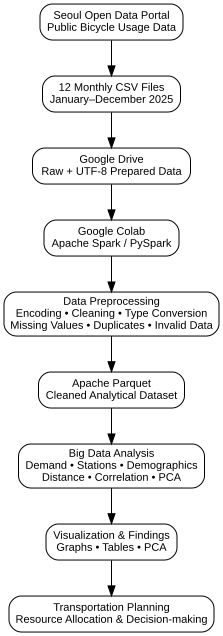

In [133]:
# Big Data Architecture Diagram

!pip -q install graphviz

from graphviz import Digraph
from IPython.display import display

dot = Digraph(
    "Seoul_Ttareungi_Big_Data_Architecture",
    format="png"
)

dot.attr(
    rankdir="TB",
    bgcolor="white",
    fontname="Arial"
)

dot.attr(
    "node",
    shape="box",
    style="rounded",
    fontname="Arial",
    fontsize="11"
)

dot.node(
    "source",
    "Seoul Open Data Portal\n"
    "Public Bicycle Usage Data"
)

dot.node(
    "csv",
    "12 Monthly CSV Files\n"
    "January–December 2025"
)

dot.node(
    "drive",
    "Google Drive\n"
    "Raw + UTF-8 Prepared Data"
)

dot.node(
    "spark",
    "Google Colab\n"
    "Apache Spark / PySpark"
)

dot.node(
    "preprocess",
    "Data Preprocessing\n"
    "Encoding • Cleaning • Type Conversion\n"
    "Missing Values • Duplicates • Invalid Data"
)

dot.node(
    "parquet",
    "Apache Parquet\n"
    "Cleaned Analytical Dataset"
)

dot.node(
    "analysis",
    "Big Data Analysis\n"
    "Demand • Stations • Demographics\n"
    "Distance • Correlation • PCA"
)

dot.node(
    "visualization",
    "Visualization & Findings\n"
    "Graphs • Tables • PCA"
)

dot.node(
    "decision",
    "Transportation Planning\n"
    "Resource Allocation & Decision-making"
)

dot.edges([
    ("source", "csv"),
    ("csv", "drive"),
    ("drive", "spark"),
    ("spark", "preprocess"),
    ("preprocess", "parquet"),
    ("parquet", "analysis"),
    ("analysis", "visualization"),
    ("visualization", "decision")
])

display(dot)

# Conceptual Big Data Architecture

The conceptual architecture is designed around the three major characteristics of
Big Data: **Volume, Velocity, and Variety**.

### Volume

The dataset contains 33,396,750 records across 12 monthly files. The large number of
records requires scalable processing. Apache Spark is therefore used instead of
performing the complete analysis with conventional single-machine processing.

### Velocity

The selected dataset contains historical monthly records rather than a live
real-time stream. However, the architecture supports incremental ingestion because
new monthly transportation files can be added to the data source and processed
through the same Spark pipeline.

### Variety

The dataset contains multiple types of attributes, including:

- Temporal attributes: rental date and rental hour
- Spatial attributes: station ID and station name
- Categorical attributes: gender, age group, and rental type
- Numerical attributes: usage count, distance, exercise amount, and carbon saved

Therefore, the architecture supports temporal, spatial, categorical, and numerical
data analysis.

### Scalability

The use of Apache Spark allows the processing workflow to scale to larger datasets
and additional transportation records. Apache Parquet is used as the analytical
storage format because it is column-oriented and suitable for analytical workloads.

### Conceptual Flow

Data Source
→ Data Ingestion
→ Distributed Storage
→ Spark Processing
→ Cleaned Data
→ Analytical Processing
→ Visualization
→ Transportation Decision-making

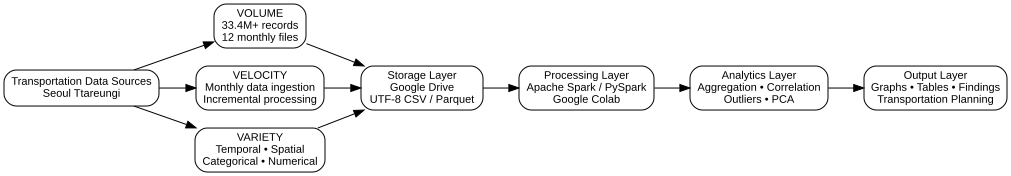

In [134]:
# Conceptual Big Data Architecture: Volume, Velocity, Variety

dot2 = Digraph(
    "Conceptual_Big_Data_Architecture",
    format="png"
)

dot2.attr(
    rankdir="LR",
    bgcolor="white",
    fontname="Arial"
)

dot2.attr(
    "node",
    shape="box",
    style="rounded",
    fontname="Arial",
    fontsize="11"
)

dot2.node(
    "data",
    "Transportation Data Sources\n"
    "Seoul Ttareungi"
)

dot2.node(
    "v",
    "VOLUME\n"
    "33.4M+ records\n"
    "12 monthly files"
)

dot2.node(
    "vel",
    "VELOCITY\n"
    "Monthly data ingestion\n"
    "Incremental processing"
)

dot2.node(
    "var",
    "VARIETY\n"
    "Temporal • Spatial\n"
    "Categorical • Numerical"
)

dot2.node(
    "storage",
    "Storage Layer\n"
    "Google Drive\n"
    "UTF-8 CSV / Parquet"
)

dot2.node(
    "processing",
    "Processing Layer\n"
    "Apache Spark / PySpark\n"
    "Google Colab"
)

dot2.node(
    "analytics",
    "Analytics Layer\n"
    "Aggregation • Correlation\n"
    "Outliers • PCA"
)

dot2.node(
    "output",
    "Output Layer\n"
    "Graphs • Tables • Findings\n"
    "Transportation Planning"
)

dot2.edge("data", "v")
dot2.edge("data", "vel")
dot2.edge("data", "var")

dot2.edge("v", "storage")
dot2.edge("vel", "storage")
dot2.edge("var", "storage")

dot2.edge("storage", "processing")
dot2.edge("processing", "analytics")
dot2.edge("analytics", "output")

display(dot2)

In [38]:
!pip install -q "pyspark[connect]~=4.0.0"

In [39]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
import os
import glob
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA

In [41]:
spark = (
    SparkSession.builder
    .appName("Seoul_Ttareungi_2025_Big_Data_Analytics")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "200")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")

print("Apache Spark Version:", spark.version)
print("Big Data Environment: Google Colab + PySpark")
print("Status: Ready")

Apache Spark Version: 4.0.4
Big Data Environment: Google Colab + PySpark
Status: Ready


In [42]:
DATA_FOLDER = "/content/drive/MyDrive/Seoul_Bicycle_Data"

print("Folder exists:", os.path.exists(DATA_FOLDER))

if os.path.exists(DATA_FOLDER):
    print("\nFiles in folder:")
    for file in os.listdir(DATA_FOLDER):
        print(file)
else:
    print("\nERROR: Change DATA_FOLDER to your actual Google Drive folder path.")

Folder exists: True

Files in folder:
서울특별시 공공자전거 이용정보(시간대별)_202502.csv
서울특별시 공공자전거 이용정보(시간대별)_202501.csv
서울특별시 공공자전거 이용정보(시간대별)_202503.csv
서울특별시 공공자전거 이용정보(시간대별)_202504.csv
서울특별시 공공자전거 이용정보(시간대별)_202505.csv
서울특별시 공공자전거 이용정보(시간대별)_202508.csv
서울특별시 공공자전거 이용정보(시간대별)_202506.csv
서울특별시 공공자전거 이용정보(시간대별)_202510.csv
서울특별시 공공자전거 이용정보(시간대별)_202512.csv
서울특별시 공공자전거 이용정보(시간대별)_202509.csv
서울특별시 공공자전거 이용정보(시간대별)_202507.csv
서울특별시 공공자전거 이용정보(시간대별)_202511.csv


In [43]:
csv_files = sorted(
    glob.glob(os.path.join(DATA_FOLDER, "**", "*.csv"), recursive=True) +
    glob.glob(os.path.join(DATA_FOLDER, "**", "*.CSV"), recursive=True)
)

print("TOTAL CSV FILES FOUND:", len(csv_files))

total_size_mb = 0

for i, file in enumerate(csv_files, 1):
    size_mb = os.path.getsize(file) / (1024 * 1024)
    total_size_mb += size_mb
    print(f"{i:02d}. {os.path.basename(file)} | {size_mb:.2f} MB")

print("\nTOTAL RAW DATA SIZE: {:.2f} MB".format(total_size_mb))

TOTAL CSV FILES FOUND: 12
01. 서울특별시 공공자전거 이용정보(시간대별)_202501.csv | 155.02 MB
02. 서울특별시 공공자전거 이용정보(시간대별)_202502.csv | 73.05 MB
03. 서울특별시 공공자전거 이용정보(시간대별)_202503.csv | 255.43 MB
04. 서울특별시 공공자전거 이용정보(시간대별)_202504.csv | 317.24 MB
05. 서울특별시 공공자전거 이용정보(시간대별)_202505.csv | 337.19 MB
06. 서울특별시 공공자전거 이용정보(시간대별)_202506.csv | 351.54 MB
07. 서울특별시 공공자전거 이용정보(시간대별)_202507.csv | 324.55 MB
08. 서울특별시 공공자전거 이용정보(시간대별)_202508.csv | 328.03 MB
09. 서울특별시 공공자전거 이용정보(시간대별)_202509.csv | 361.94 MB
10. 서울특별시 공공자전거 이용정보(시간대별)_202510.csv | 312.89 MB
11. 서울특별시 공공자전거 이용정보(시간대별)_202511.csv | 294.94 MB
12. 서울특별시 공공자전거 이용정보(시간대별)_202512.csv | 185.53 MB

TOTAL RAW DATA SIZE: 3297.35 MB


In [44]:
ENCODINGS = ["utf-8-sig", "utf-8", "cp949", "euc-kr"]

def detect_encoding_and_preview(file_path):
    for enc in ENCODINGS:
        try:
            preview = pd.read_csv(file_path, nrows=5, encoding=enc)
            return enc, preview
        except Exception:
            pass
    raise ValueError(f"Could not read: {file_path}")

sample_file = csv_files[0]

sample_encoding, sample_df = detect_encoding_and_preview(sample_file)

print("Sample file:", os.path.basename(sample_file))
print("Detected encoding:", sample_encoding)

print("\nACTUAL COLUMN NAMES:")
for i, col in enumerate(sample_df.columns, 1):
    print(f"{i}. {repr(col)}")

display(sample_df.head())

Sample file: 서울특별시 공공자전거 이용정보(시간대별)_202501.csv
Detected encoding: cp949

ACTUAL COLUMN NAMES:
1. '대여일자'
2. '대여시간'
3. '대여소번호'
4. '대여소명'
5. '대여구분코드'
6. '성별'
7. '연령대코드'
8. '이용건수'
9. '운동량'
10. '탄소량'
11. '이동거리'


,대여일자,대여시간,대여소번호,대여소명,대여구분코드,성별,연령대코드,이용건수,운동량,탄소량,이동거리
0,2025-01-01,0,3684,3684. 고덕자이(105동 앞),정기권,NaN,~10대,1,119.90,1.10,4730.80
1,2025-01-01,0,1044,1044. 굽은다리역,정기권,NaN,20대,1,24.46,0.30,1314.19
2,2025-01-01,0,1153,"1153. 발산역 1번, 9번 인근 대여소",정기권,NaN,20대,1,21.21,0.23,992.04
3,2025-01-01,0,1260,1260. 방이동 한양3차아파트 옆,정기권,NaN,20대,1,73.21,0.74,3187.35
4,2025-01-01,0,1845,1845. 롯데캐슬골드파크1차 서문,정기권,NaN,20대,1,53.80,0.48,2090.00


In [45]:
files = sorted(
    glob.glob(DATA_FOLDER + "/**/*.csv", recursive=True) +
    glob.glob(DATA_FOLDER + "/**/*.CSV", recursive=True)
)

print("TOTAL CSV FILES FOUND:", len(files))

total_size_mb = 0

for i, file in enumerate(files, 1):

    size_mb = os.path.getsize(file) / (1024 * 1024)
    total_size_mb += size_mb

    print(
        f"{i:02d}. {os.path.basename(file)} "
        f"| {size_mb:.2f} MB"
    )

print("\nTOTAL DATA SIZE:", round(total_size_mb, 2), "MB")

TOTAL CSV FILES FOUND: 12
01. 서울특별시 공공자전거 이용정보(시간대별)_202501.csv | 155.02 MB
02. 서울특별시 공공자전거 이용정보(시간대별)_202502.csv | 73.05 MB
03. 서울특별시 공공자전거 이용정보(시간대별)_202503.csv | 255.43 MB
04. 서울특별시 공공자전거 이용정보(시간대별)_202504.csv | 317.24 MB
05. 서울특별시 공공자전거 이용정보(시간대별)_202505.csv | 337.19 MB
06. 서울특별시 공공자전거 이용정보(시간대별)_202506.csv | 351.54 MB
07. 서울특별시 공공자전거 이용정보(시간대별)_202507.csv | 324.55 MB
08. 서울특별시 공공자전거 이용정보(시간대별)_202508.csv | 328.03 MB
09. 서울특별시 공공자전거 이용정보(시간대별)_202509.csv | 361.94 MB
10. 서울특별시 공공자전거 이용정보(시간대별)_202510.csv | 312.89 MB
11. 서울특별시 공공자전거 이용정보(시간대별)_202511.csv | 294.94 MB
12. 서울특별시 공공자전거 이용정보(시간대별)_202512.csv | 185.53 MB

TOTAL DATA SIZE: 3297.35 MB


In [46]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("SeoulBicycleAnalysis")
    .getOrCreate()
)

print("Spark version:", spark.version)

Spark version: 4.0.4


In [47]:
print("Number of files:", len(files))
print("Encoding:", sample_encoding)

for f in files:
    print(f)

Number of files: 12
Encoding: cp949
/content/drive/MyDrive/Seoul_Bicycle_Data/서울특별시 공공자전거 이용정보(시간대별)_202501.csv
/content/drive/MyDrive/Seoul_Bicycle_Data/서울특별시 공공자전거 이용정보(시간대별)_202502.csv
/content/drive/MyDrive/Seoul_Bicycle_Data/서울특별시 공공자전거 이용정보(시간대별)_202503.csv
/content/drive/MyDrive/Seoul_Bicycle_Data/서울특별시 공공자전거 이용정보(시간대별)_202504.csv
/content/drive/MyDrive/Seoul_Bicycle_Data/서울특별시 공공자전거 이용정보(시간대별)_202505.csv
/content/drive/MyDrive/Seoul_Bicycle_Data/서울특별시 공공자전거 이용정보(시간대별)_202506.csv
/content/drive/MyDrive/Seoul_Bicycle_Data/서울특별시 공공자전거 이용정보(시간대별)_202507.csv
/content/drive/MyDrive/Seoul_Bicycle_Data/서울특별시 공공자전거 이용정보(시간대별)_202508.csv
/content/drive/MyDrive/Seoul_Bicycle_Data/서울특별시 공공자전거 이용정보(시간대별)_202509.csv
/content/drive/MyDrive/Seoul

In [48]:
import os
import glob

utf8_folder = "/content/drive/MyDrive/Seoul_Bicycle_Data_UTF8"
os.makedirs(utf8_folder, exist_ok=True)

for file in files:
    filename = os.path.basename(file)
    output_file = os.path.join(utf8_folder, filename)

    with open(file, "r", encoding="cp949") as f:
        content = f.read()

    with open(output_file, "w", encoding="utf-8") as f:
        f.write(content)

print("Conversion complete!")
print("UTF-8 files:", len(glob.glob(utf8_folder + "/*.csv")))

Conversion complete!
UTF-8 files: 12


In [49]:
utf8_files = sorted(
    glob.glob(os.path.join(utf8_folder, "*.csv"))
)

raw = (
    spark.read
    .option("header", "true")
    .option("encoding", "UTF-8")
    .option("mode", "PERMISSIVE")
    .option("inferSchema", "true")
    .csv(utf8_files)
)

print("Original Korean columns:")
print(raw.columns)

print("\nRaw Schema:")
raw.printSchema()

print("\nFirst 5 rows:")
raw.show(5, truncate=False)

Original Korean columns:
['대여일자', '대여시간', '대여소번호', '대여소명', '대여구분코드', '성별', '연령대코드', '이용건수', '운동량', '탄소량', '이동거리']

Raw Schema:
root
 |-- 대여일자: string (nullable = true)
 |-- 대여시간: string (nullable = true)
 |-- 대여소번호: string (nullable = true)
 |-- 대여소명: string (nullable = true)
 |-- 대여구분코드: string (nullable = true)
 |-- 성별: string (nullable = true)
 |-- 연령대코드: string (nullable = true)
 |-- 이용건수: string (nullable = true)
 |-- 운동량: string (nullable = true)
 |-- 탄소량: string (nullable = true)
 |-- 이동거리: string (nullable = true)


First 5 rows:
+----------+--------+----------+---------------------------------+------------+----+----------+--------+------+------+--------+
|대여일자  |대여시간|대여소번호|대여소명                         |대여구분코드|성별|연령대코드|이용건수|운동량|탄소량|이동거리|
+----------+--------+----------+---------------------------------+------------+----+----------+--------+------+------+--------+
|2025-01-01|0       |03684     |3684. 고덕자이(105동 앞)         |정기권      |NULL|~10대     |1       |119.90|1.10  |4730.80 

In [50]:
column_mapping = {

    "대여일자": "rental_date",
    "대여시간": "rental_hour",
    "대여소번호": "station_id",
    "대여소명": "station_name",
    "대여구분코드": "rental_type",
    "성별": "gender",
    "연령대코드": "age_group",
    "이용건수": "usage_count",
    "운동량": "exercise_amount",
    "탄소량": "carbon_saved",
    "이동거리": "distance_m"
}

for korean, english in column_mapping.items():

    if korean in raw.columns:
        raw = raw.withColumnRenamed(
            korean,
            english
        )
    else:
        print(
            f"WARNING: Column not found: {korean}"
        )

print("English column names:")
print(raw.columns)

English column names:
['rental_date', 'rental_hour', 'station_id', 'station_name', 'rental_type', 'gender', 'age_group', 'usage_count', 'exercise_amount', 'carbon_saved', 'distance_m']


In [51]:
from pyspark.sql import functions as F

raw = (
    raw
    .withColumn(
        "rental_type",
        F.when(F.col("rental_type") == "정기권", "Annual Pass")
         .when(F.col("rental_type") == "일일권", "Daily Pass")
         .otherwise(F.col("rental_type"))
    )
    .withColumn(
        "age_group",
        F.when(F.col("age_group") == "~10대", "Under 10")
         .when(F.col("age_group") == "10대", "Teens")
         .when(F.col("age_group") == "20대", "20s")
         .when(F.col("age_group") == "30대", "30s")
         .when(F.col("age_group") == "40대", "40s")
         .when(F.col("age_group") == "50대", "50s")
         .when(F.col("age_group") == "60대", "60s")
         .when(F.col("age_group") == "70대", "70s")
         .otherwise(F.col("age_group"))
    )
)

In [52]:
from pyspark.sql import functions as F

raw = (
    raw
    .withColumn(
        "station_name_en",
        F.col("station_name")
    )

    # Common Korean location/transport terms
    .withColumn(
        "station_name_en",
        F.regexp_replace(
            F.col("station_name_en"),
            "인근 대여소",
            " Nearby Bike Station"
        )
    )
    .withColumn(
        "station_name_en",
        F.regexp_replace(
            F.col("station_name_en"),
            "대여소",
            " Bike Station"
        )
    )
    .withColumn(
        "station_name_en",
        F.regexp_replace(
            F.col("station_name_en"),
            "역",
            " Station"
        )
    )
    .withColumn(
        "station_name_en",
        F.regexp_replace(
            F.col("station_name_en"),
            "앞",
            " Front"
        )
    )
    .withColumn(
        "station_name_en",
        F.regexp_replace(
            F.col("station_name_en"),
            "옆",
            " Next to"
        )
    )
    .withColumn(
        "station_name_en",
        F.regexp_replace(
            F.col("station_name_en"),
            "서문",
            " West Gate"
        )
    )
)

raw.select(
    "station_id",
    "station_name",
    "station_name_en"
).show(20, truncate=False)

+----------+---------------------------------+------------------------------------------------+
|station_id|station_name                     |station_name_en                                 |
+----------+---------------------------------+------------------------------------------------+
|03684     |3684. 고덕자이(105동 앞)         |3684. 고덕자이(105동  Front)                    |
|01044     |1044. 굽은다리역                 |1044. 굽은다리 Station                          |
|01153     |1153. 발산역 1번, 9번 인근 대여소|1153. 발산 Station 1번, 9번  Nearby Bike Station|
|01260     |1260. 방이동 한양3차아파트 옆    |1260. 방이동 한양3차아파트  Next to             |
|01845     |1845. 롯데캐슬골드파크1차 서문   |1845. 롯데캐슬골드파크1차  West Gate            |
|01338     |1338. 용문2교 옆                 |1338. 용문2교  Next to                          |
|01725     |1725. 창1동주민센터              |1725. 창1동주민센터                             |
|01452     |1452. 겸재교 진입부              |1452. 겸재교 진입부                             |
|01278     |1278. 송파구청 교차로            |1278. 송파구

In [53]:
!pip install hangul-romanize -q

In [54]:
from hangul_romanize import Transliter
from hangul_romanize.rule import academic

transliter = Transliter(academic)

# Get unique station names
station_names = (
    raw
    .select("station_name")
    .distinct()
    .toPandas()
)

# Romanize Korean station names
station_names["station_name_en"] = (
    station_names["station_name"]
    .apply(lambda x: transliter.translit(x) if x is not None else None)
)

display(station_names.head(20))

,station_name,station_name_en
0,1166. 강서구립등빛도서관,1166. gangseogulibdeungbichdoseogwan
1,2328. 르네상스 호텔 사거리 역삼지하보도 7번출구 앞,2328. leunesangseu hotel sageoli yeogsamjihabo...
2,3002.벽산상암스마트큐브,3002.byeogsansang-amseumateukyubeu
3,568. 청계8가 사거리 B,568. cheonggye8ga sageoli B
4,2116. 에이스에이존빌딩,2116. e-iseu-e-ijonbilding
5,1870.독산3동주민센터 앞,1870.dogsan3dongjuminsenteo ap
6,4173. 중대후문 마을버스정류장,4173. jungdaehumun ma-eulbeoseujeonglyujang
7,300. 정동사거리,300. jeongdongsageoli
8,2293. SPC 앞,2293. SPC ap
9,429. 송도병원,429. songdobyeong-won


In [55]:
station_mapping = spark.createDataFrame(
    station_names[["station_name", "station_name_en"]]
)

In [56]:
raw = (
    raw
    .drop("station_name_en")
    .join(
        station_mapping,
        on="station_name",
        how="left"
    )
)

In [57]:
raw.select(
    "station_id",
    "station_name",
    "station_name_en"
).show(20, truncate=False)

+----------+---------------------------------+-----------------------------------------------+
|station_id|station_name                     |station_name_en                                |
+----------+---------------------------------+-----------------------------------------------+
|01278     |1278. 송파구청 교차로            |1278. songpagucheong gyochalo                  |
|01845     |1845. 롯데캐슬골드파크1차 서문   |1845. losdekaeseulgoldeupakeu1cha seomun       |
|01364     |1364. 성북동 치안센터 앞         |1364. seongbugdong chi-ansenteo ap             |
|01184     |1184. 마곡13단지                 |1184. magog13danji                             |
|01543     |1543. 수유1동 주민센터           |1543. su-yu1dong juminsenteo                   |
|01725     |1725. 창1동주민센터              |1725. chang1dongjuminsenteo                    |
|03421     |3421.혜화역 1번출구              |3421.hyehwa-yeog 1beonchulgu                   |
|01452     |1452. 겸재교 진입부              |1452. gyeomjaegyo jin-ibbu                     |
|00335    

In [58]:
from pyspark.sql import functions as F

# Create a partially English-labelled version of the station name
raw = (
    raw
    .withColumn("station_name_en", F.col("station_name"))

    # Common Korean terms
    .withColumn(
        "station_name_en",
        F.regexp_replace("station_name_en", "인근 대여소", " Nearby Bike Station")
    )
    .withColumn(
        "station_name_en",
        F.regexp_replace("station_name_en", "대여소", " Bike Station")
    )
    .withColumn(
        "station_name_en",
        F.regexp_replace("station_name_en", "번출구", " Exit")
    )
    .withColumn(
        "station_name_en",
        F.regexp_replace("station_name_en", "출구", " Exit")
    )
    .withColumn(
        "station_name_en",
        F.regexp_replace("station_name_en", "역", " Station")
    )
    .withColumn(
        "station_name_en",
        F.regexp_replace("station_name_en", "앞", " In Front")
    )
    .withColumn(
        "station_name_en",
        F.regexp_replace("station_name_en", "뒤편", " Behind")
    )
    .withColumn(
        "station_name_en",
        F.regexp_replace("station_name_en", "옆", " Next To")
    )
    .withColumn(
        "station_name_en",
        F.regexp_replace("station_name_en", "주민센터", " Community Center")
    )
    .withColumn(
        "station_name_en",
        F.regexp_replace("station_name_en", "교차로", " Intersection")
    )
    .withColumn(
        "station_name_en",
        F.regexp_replace("station_name_en", "서문", " West Gate")
    )
    .withColumn(
        "station_name_en",
        F.regexp_replace("station_name_en", "동문", " East Gate")
    )
    .withColumn(
        "station_name_en",
        F.regexp_replace("station_name_en", "남문", " South Gate")
    )
    .withColumn(
        "station_name_en",
        F.regexp_replace("station_name_en", "북문", " North Gate")
    )
)

raw.select(
    "station_id",
    "station_name",
    "station_name_en"
).show(20, truncate=False)

+----------+---------------------------------+------------------------------------------------+
|station_id|station_name                     |station_name_en                                 |
+----------+---------------------------------+------------------------------------------------+
|01278     |1278. 송파구청 교차로            |1278. 송파구청  Intersection                    |
|01845     |1845. 롯데캐슬골드파크1차 서문   |1845. 롯데캐슬골드파크1차  West Gate            |
|01364     |1364. 성북동 치안센터 앞         |1364. 성북동 치안센터  In Front                 |
|01184     |1184. 마곡13단지                 |1184. 마곡13단지                                |
|01543     |1543. 수유1동 주민센터           |1543. 수유1동  Community Center                 |
|01725     |1725. 창1동주민센터              |1725. 창1동 Community Center                    |
|03421     |3421.혜화역 1번출구              |3421.혜화 Station 1 Exit                        |
|01452     |1452. 겸재교 진입부              |1452. 겸재교 진입부                             |
|00335     |335. 종로3가역 15번출구 앞      

In [59]:
df = (
    raw

    .withColumn(
        "rental_date",
        F.coalesce(
            F.to_date(
                F.col("rental_date"),
                "yyyy-MM-dd"
            ),
            F.to_date(
                F.col("rental_date"),
                "yyyyMMdd"
            ),
            F.to_date(
                F.col("rental_date"),
                "yyyy/MM/dd"
            )
        )
    )

    .withColumn(
        "rental_hour",
        F.col("rental_hour").cast("int")
    )

    .withColumn(
        "station_id",
        F.col("station_id").cast("string")
    )

    .withColumn(
        "station_name",
        F.trim(
            F.col("station_name")
        )
    )

    .withColumn(
        "rental_type",
        F.trim(
            F.col("rental_type")
        )
    )

    .withColumn(
        "gender",
        F.trim(
            F.col("gender")
        )
    )

    .withColumn(
        "age_group",
        F.trim(
            F.col("age_group")
        )
    )

    .withColumn(
        "usage_count",
        F.col("usage_count").cast("int")
    )

    .withColumn(
        "exercise_amount",
        F.col("exercise_amount").cast("double")
    )

    .withColumn(
        "carbon_saved",
        F.col("carbon_saved").cast("double")
    )

    .withColumn(
        "distance_m",
        F.col("distance_m").cast("double")
    )
)

df.printSchema()

df.show(5, truncate=False)

root
 |-- station_name: string (nullable = true)
 |-- rental_date: date (nullable = true)
 |-- rental_hour: integer (nullable = true)
 |-- station_id: string (nullable = true)
 |-- rental_type: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- age_group: string (nullable = true)
 |-- usage_count: integer (nullable = true)
 |-- exercise_amount: double (nullable = true)
 |-- carbon_saved: double (nullable = true)
 |-- distance_m: double (nullable = true)
 |-- station_name_en: string (nullable = true)

+---------------------------------+-----------+-----------+----------+-----------+------+---------+-----------+---------------+------------+----------+------------------------------------------------+
|station_name                     |rental_date|rental_hour|station_id|rental_type|gender|age_group|usage_count|exercise_amount|carbon_saved|distance_m|station_name_en                                 |
+---------------------------------+-----------+-----------+----------+-----

In [60]:
raw_count = df.count()

print("=" * 70)
print("SEOUL TTAREUNGI 2025 DATASET OVERVIEW")
print("=" * 70)

print("Study Period: January 2025 - December 2025")
print("Number of Files:", len(files))
print("Total Raw Records:", f"{raw_count:,}")
print("Number of Columns:", len(df.columns))
print("Total Dataset Size:", f"{total_size_mb:.2f} MB")

print("\nColumns:")
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

SEOUL TTAREUNGI 2025 DATASET OVERVIEW
Study Period: January 2025 - December 2025
Number of Files: 12
Total Raw Records: 33,396,750
Number of Columns: 12
Total Dataset Size: 3297.35 MB

Columns:
1. station_name
2. rental_date
3. rental_hour
4. station_id
5. rental_type
6. gender
7. age_group
8. usage_count
9. exercise_amount
10. carbon_saved
11. distance_m
12. station_name_en


In [61]:
date_summary = df.select(
    F.min("rental_date").alias("first_date"),
    F.max("rental_date").alias("last_date")
)

date_summary.show()

+----------+----------+
|first_date| last_date|
+----------+----------+
|2025-01-01|2025-12-31|
+----------+----------+



In [37]:
from pyspark.sql import functions as F

utf8_files = sorted(
    glob.glob("/content/drive/MyDrive/Seoul_Bicycle_Data_UTF8/*.csv")
)

print("Files found:", len(utf8_files))

raw_with_file = (
    spark.read
    .option("header", "true")
    .option("encoding", "UTF-8")
    .option("mode", "PERMISSIVE")
    .csv(utf8_files)
    .withColumn(
        "source_file",
        F.regexp_extract(
            F.input_file_name(),
            r"([^/]+$)",
            1
        )
    )
)

for korean, english in column_mapping.items():
    if korean in raw_with_file.columns:
        raw_with_file = raw_with_file.withColumnRenamed(
            korean,
            english
        )

raw_with_file.groupBy(
    "source_file"
).count().orderBy(
    "source_file"
).show(20, truncate=False)

Files found: 12
+-----------------------------------------------------------------------------------+-------+
|source_file                                                                        |count  |
+-----------------------------------------------------------------------------------+-------+
|서울특별시%20공공자전거%20이용정보(시간대별)_202501.csv|1610875|
|서울특별시%20공공자전거%20이용정보(시간대별)_202502.csv|759111 |
|서울특별시%20공공자전거%20이용정보(시간대별)_202503.csv|2651685|
|서울특별시%20공공자전거%20이용정보(시간대별)_202504.csv|3290558|
|서울특별시%20공공자전거%20이용정보(시간대별)_202505.csv|3495294|
|서울특별시%20공공자전거%20이용정보(시간대별)_202506.csv|3644614|
|서울특별시%20공공자전거%20이용정보(시간대별)_202507.csv|3222854|
|서울특별시%20공공자전거%20이용정보(시간대별)_202508.csv|3254970|
|서울특별시%20공공자전거%20이용정보(시간대별)_202509.csv|3590200|
|서울특별시%20ᄀ

In [63]:
df = (
    df
    .withColumn(
        "rental_date",
        F.coalesce(
            F.to_date(F.col("rental_date"), "yyyy-MM-dd"),
            F.to_date(F.col("rental_date"), "yyyyMMdd"),
            F.to_date(F.col("rental_date"), "yyyy/MM/dd")
        )
    )
    .withColumn(
        "rental_hour",
        F.col("rental_hour").cast("int")
    )
    .withColumn(
        "station_id",
        F.col("station_id").cast("string")
    )
    .withColumn(
        "station_name",
        F.trim(F.col("station_name"))
    )
    .withColumn(
        "rental_type",
        F.trim(F.col("rental_type"))
    )
    .withColumn(
        "gender",
        F.trim(F.col("gender"))
    )
    .withColumn(
        "age_group",
        F.trim(F.col("age_group"))
    )
    .withColumn(
        "usage_count",
        F.col("usage_count").cast("int")
    )
    .withColumn(
        "exercise_amount",
        F.col("exercise_amount").cast("double")
    )
    .withColumn(
        "carbon_saved",
        F.col("carbon_saved").cast("double")
    )
    .withColumn(
        "distance_m",
        F.col("distance_m").cast("double")
    )
)

df.printSchema()
df.show(5, truncate=False)

root
 |-- station_name: string (nullable = true)
 |-- rental_date: date (nullable = true)
 |-- rental_hour: integer (nullable = true)
 |-- station_id: string (nullable = true)
 |-- rental_type: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- age_group: string (nullable = true)
 |-- usage_count: integer (nullable = true)
 |-- exercise_amount: double (nullable = true)
 |-- carbon_saved: double (nullable = true)
 |-- distance_m: double (nullable = true)
 |-- station_name_en: string (nullable = true)

+--------------------------------------------------+-----------+-----------+----------+-----------+------+---------+-----------+---------------+------------+----------+--------------------------------------------------------------+
|station_name                                      |rental_date|rental_hour|station_id|rental_type|gender|age_group|usage_count|exercise_amount|carbon_saved|distance_m|station_name_en                                               |
+------------

In [67]:
from pyspark.sql import functions as F

# Convert \N, empty strings, and "null" strings to actual NULL values
def clean_string(col_name):
    return F.when(
        F.trim(F.col(col_name)).isin("", "\\N", "null", "NULL"),
        None
    ).otherwise(F.trim(F.col(col_name)))

df = (
    raw
    .withColumn(
        "rental_date",
        F.coalesce(
            F.to_date(clean_string("rental_date"), "yyyy-MM-dd"),
            F.to_date(clean_string("rental_date"), "yyyyMMdd"),
            F.to_date(clean_string("rental_date"), "yyyy/MM/dd")
        )
    )
    .withColumn(
        "rental_hour",
        clean_string("rental_hour").cast("int")
    )
    .withColumn(
        "station_id",
        clean_string("station_id")
    )
    .withColumn(
        "station_name",
        clean_string("station_name")
    )
    .withColumn(
        "rental_type",
        clean_string("rental_type")
    )
    .withColumn(
        "gender",
        clean_string("gender")
    )
    .withColumn(
        "age_group",
        clean_string("age_group")
    )
    .withColumn(
        "usage_count",
        clean_string("usage_count").cast("int")
    )
    .withColumn(
        "exercise_amount",
        clean_string("exercise_amount").cast("double")
    )
    .withColumn(
        "carbon_saved",
        clean_string("carbon_saved").cast("double")
    )
    .withColumn(
        "distance_m",
        clean_string("distance_m").cast("double")
    )
)

print("DataFrame rebuilt successfully.")
df.printSchema()
df.show(5, truncate=False)

DataFrame rebuilt successfully.
root
 |-- station_name: string (nullable = true)
 |-- rental_date: date (nullable = true)
 |-- rental_hour: integer (nullable = true)
 |-- station_id: string (nullable = true)
 |-- rental_type: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- age_group: string (nullable = true)
 |-- usage_count: integer (nullable = true)
 |-- exercise_amount: double (nullable = true)
 |-- carbon_saved: double (nullable = true)
 |-- distance_m: double (nullable = true)
 |-- station_name_en: string (nullable = true)

+---------------------------------+-----------+-----------+----------+-----------+------+---------+-----------+---------------+------------+----------+------------------------------------------------+
|station_name                     |rental_date|rental_hour|station_id|rental_type|gender|age_group|usage_count|exercise_amount|carbon_saved|distance_m|station_name_en                                 |
+---------------------------------+--------

In [69]:
from pyspark.sql import functions as F

# Replace invalid missing-value markers with actual NULL
def clean_string(col_name):
    return F.when(
        F.trim(F.col(col_name)).isin("", "\\N", "null", "NULL"),
        None
    ).otherwise(F.trim(F.col(col_name)))

df = (
    raw

    .withColumn(
        "rental_date",
        F.coalesce(
            F.to_date(clean_string("rental_date"), "yyyy-MM-dd"),
            F.to_date(clean_string("rental_date"), "yyyyMMdd"),
            F.to_date(clean_string("rental_date"), "yyyy/MM/dd")
        )
    )

    .withColumn(
        "rental_hour",
        clean_string("rental_hour").cast("int")
    )

    .withColumn(
        "station_id",
        clean_string("station_id")
    )

    .withColumn(
        "station_name",
        clean_string("station_name")
    )

    .withColumn(
        "rental_type",
        clean_string("rental_type")
    )

    .withColumn(
        "gender",
        clean_string("gender")
    )

    .withColumn(
        "age_group",
        clean_string("age_group")
    )

    .withColumn(
        "usage_count",
        clean_string("usage_count").cast("int")
    )

    .withColumn(
        "exercise_amount",
        clean_string("exercise_amount").cast("double")
    )

    .withColumn(
        "carbon_saved",
        clean_string("carbon_saved").cast("double")
    )

    .withColumn(
        "distance_m",
        clean_string("distance_m").cast("double")
    )
)

print("df created successfully!")
df.printSchema()

df created successfully!
root
 |-- station_name: string (nullable = true)
 |-- rental_date: date (nullable = true)
 |-- rental_hour: integer (nullable = true)
 |-- station_id: string (nullable = true)
 |-- rental_type: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- age_group: string (nullable = true)
 |-- usage_count: integer (nullable = true)
 |-- exercise_amount: double (nullable = true)
 |-- carbon_saved: double (nullable = true)
 |-- distance_m: double (nullable = true)
 |-- station_name_en: string (nullable = true)



In [70]:
df.show(5, truncate=False)

+---------------------------------+-----------+-----------+----------+-----------+------+---------+-----------+---------------+------------+----------+------------------------------------------------+
|station_name                     |rental_date|rental_hour|station_id|rental_type|gender|age_group|usage_count|exercise_amount|carbon_saved|distance_m|station_name_en                                 |
+---------------------------------+-----------+-----------+----------+-----------+------+---------+-----------+---------------+------------+----------+------------------------------------------------+
|1845. 롯데캐슬골드파크1차 서문   |2025-01-01 |0          |01845     |Annual Pass|NULL  |20s      |1          |53.8           |0.48        |2090.0    |1845. 롯데캐슬골드파크1차  West Gate            |
|1153. 발산역 1번, 9번 인근 대여소|2025-01-01 |0          |01153     |Annual Pass|NULL  |20s      |1          |21.21          |0.23        |992.04    |1153. 발산 Station 1번, 9번  Nearby Bike Station|
|1338. 용문2교 옆                

In [71]:
print("Total rows:", df.count())

Total rows: 33396750


In [74]:
# Cache the dataframe in memory/disk
df = df.persist()

# Materialize the cache ONCE
print("Caching dataframe...")
total_rows = df.count()

print(f"Total records: {total_rows:,}")

Caching dataframe...
Total records: 33,396,750


In [76]:
# CELL — Save prepared dataframe as Parquet

PARQUET_RAW = "/content/drive/MyDrive/Seoul_Ttareungi_2025_Prepared_Parquet"

print("Saving prepared dataset as Parquet...")

df.write \
    .mode("overwrite") \
    .parquet(PARQUET_RAW)

print("✓ Parquet saved successfully")
print(PARQUET_RAW)

Saving prepared dataset as Parquet...
✓ Parquet saved successfully
/content/drive/MyDrive/Seoul_Ttareungi_2025_Prepared_Parquet


In [77]:
# CELL — Load prepared Parquet

df = spark.read.parquet(PARQUET_RAW)

print("Records:", f"{df.count():,}")

df.printSchema()

Records: 33,396,750
root
 |-- station_name: string (nullable = true)
 |-- rental_date: date (nullable = true)
 |-- rental_hour: integer (nullable = true)
 |-- station_id: string (nullable = true)
 |-- rental_type: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- age_group: string (nullable = true)
 |-- usage_count: integer (nullable = true)
 |-- exercise_amount: double (nullable = true)
 |-- carbon_saved: double (nullable = true)
 |-- distance_m: double (nullable = true)
 |-- station_name_en: string (nullable = true)



In [78]:
# CELL 14 — Missing-value analysis

total_rows = df.count()

missing_expressions = []

for col in df.columns:
    missing_expressions.append(
        F.sum(
            F.when(
                F.col(col).isNull() |
                (F.trim(F.col(col).cast("string")) == "") |
                (
                    F.lower(
                        F.trim(F.col(col).cast("string"))
                    ) == "null"
                ) |
                (
                    F.trim(F.col(col).cast("string")) == "\\N"
                ),
                1
            ).otherwise(0)
        ).alias(col)
    )

missing_row = df.agg(*missing_expressions).first()

missing_results = []

for col in df.columns:
    missing_count = missing_row[col]

    missing_results.append([
        col,
        missing_count,
        round(missing_count / total_rows * 100, 4)
    ])

missing_pd = pd.DataFrame(
    missing_results,
    columns=[
        "Column",
        "Missing_Count",
        "Missing_Percent"
    ]
).sort_values(
    "Missing_Percent",
    ascending=False
).reset_index(drop=True)

display(missing_pd)

,Column,Missing_Count,Missing_Percent
0,gender,8584865,25.7057
1,exercise_amount,162084,0.4853
2,carbon_saved,162084,0.4853
3,station_name,0,0.0000
4,station_id,0,0.0000
5,rental_hour,0,0.0000
6,rental_date,0,0.0000
7,rental_type,0,0.0000
8,usage_count,0,0.0000
9,age_group,0,0.0000


In [79]:
# ============================================================
# CELL 14 — Duplicate analysis
# ============================================================

total_before_duplicates = df.count()

distinct_count = df.dropDuplicates().count()

duplicate_count = (
    total_before_duplicates - distinct_count
)

duplicate_percent = (
    duplicate_count / total_before_duplicates * 100
)

print("Total records:", f"{total_before_duplicates:,}")
print("Distinct records:", f"{distinct_count:,}")
print("Duplicate records:", f"{duplicate_count:,}")
print("Duplicate percentage:", f"{duplicate_percent:.4f}%")

Total records: 33,396,750
Distinct records: 33,396,093
Duplicate records: 657
Duplicate percentage: 0.0020%


In [80]:
# ============================================================
# CELL 15 — Remove duplicates
# ============================================================

df_clean = df.dropDuplicates()

after_duplicate_removal = df_clean.count()

print(
    "Before duplicate removal:",
    f"{total_before_duplicates:,}"
)

print(
    "After duplicate removal:",
    f"{after_duplicate_removal:,}"
)

print(
    "Duplicates removed:",
    f"{total_before_duplicates - after_duplicate_removal:,}"
)

Before duplicate removal: 33,396,750
After duplicate removal: 33,396,093
Duplicates removed: 657


In [81]:
# ============================================================
# CELL 16 — Inspect suspicious numeric values
# ============================================================

df_clean.select(
    F.min("rental_hour").alias("min_hour"),
    F.max("rental_hour").alias("max_hour"),

    F.min("usage_count").alias("min_usage"),
    F.max("usage_count").alias("max_usage"),

    F.min("distance_m").alias("min_distance"),
    F.max("distance_m").alias("max_distance"),

    F.min("exercise_amount").alias("min_exercise"),
    F.max("exercise_amount").alias("max_exercise"),

    F.min("carbon_saved").alias("min_carbon"),
    F.max("carbon_saved").alias("max_carbon")
).show(truncate=False)

+--------+--------+---------+---------+------------+------------+------------+------------+----------+----------+
|min_hour|max_hour|min_usage|max_usage|min_distance|max_distance|min_exercise|max_exercise|min_carbon|max_carbon|
+--------+--------+---------+---------+------------+------------+------------+------------+----------+----------+
|0       |23      |1        |28       |0.0         |354851.61   |0.0         |84333.82    |0.0       |82.33     |
+--------+--------+---------+---------+------------+------------+------------+------------+----------+----------+



In [82]:
# ============================================================
# CELL 17 — Handle missing essential data
# ============================================================

before_missing_treatment = df_clean.count()

df_clean = df_clean.dropna(
    subset=[
        "rental_date",
        "rental_hour",
        "station_id",
        "usage_count"
    ]
)

after_missing_treatment = df_clean.count()

print(
    "Before missing-value treatment:",
    f"{before_missing_treatment:,}"
)

print(
    "After missing-value treatment:",
    f"{after_missing_treatment:,}"
)

print(
    "Records removed:",
    f"{before_missing_treatment - after_missing_treatment:,}"
)

Before missing-value treatment: 33,396,093
After missing-value treatment: 33,396,093
Records removed: 0


In [84]:
# CELL 19 — Remove invalid/inconsistent records

before_invalid_treatment = df_clean.count()

df_clean = df_clean.filter(

    (F.col("rental_hour") >= 0) &
    (F.col("rental_hour") <= 23) &

    (F.col("usage_count") > 0) &

    (
        F.col("distance_m").isNull() |
        (F.col("distance_m") > 0)
    ) &

    (
        F.col("exercise_amount").isNull() |
        (F.col("exercise_amount") >= 0)
    ) &

    (
        F.col("carbon_saved").isNull() |
        (F.col("carbon_saved") >= 0)
    )
)

after_invalid_treatment = df_clean.count()

print(
    "Before invalid-data treatment:",
    f"{before_invalid_treatment:,}"
)

print(
    "After invalid-data treatment:",
    f"{after_invalid_treatment:,}"
)

print(
    "Invalid records removed:",
    f"{before_invalid_treatment - after_invalid_treatment:,}"
)

Before invalid-data treatment: 33,396,093
After invalid-data treatment: 32,997,961
Invalid records removed: 398,132


In [85]:
# ============================================================
# CELL 20 — Feature engineering
# ============================================================

df_clean = (
    df_clean

    .withColumn(
        "month",
        F.month("rental_date")
    )

    .withColumn(
        "day_of_week",
        F.dayofweek("rental_date")
    )

    .withColumn(
        "day_type",
        F.when(
            F.col("day_of_week").isin(1, 7),
            "Weekend"
        ).otherwise("Weekday")
    )

    .withColumn(
        "year",
        F.year("rental_date")
    )
)

df_clean.select(
    "rental_date",
    "rental_hour",
    "month",
    "day_of_week",
    "day_type",
    "usage_count"
).show(10, truncate=False)

+-----------+-----------+-----+-----------+--------+-----------+
|rental_date|rental_hour|month|day_of_week|day_type|usage_count|
+-----------+-----------+-----+-----------+--------+-----------+
|2025-01-01 |19         |1    |4          |Weekday |2          |
|2025-01-01 |23         |1    |4          |Weekday |1          |
|2025-01-02 |13         |1    |5          |Weekday |2          |
|2025-01-02 |19         |1    |5          |Weekday |2          |
|2025-01-04 |8          |1    |7          |Weekend |1          |
|2025-01-04 |9          |1    |7          |Weekend |1          |
|2025-01-04 |19         |1    |7          |Weekend |1          |
|2025-01-05 |13         |1    |1          |Weekend |1          |
|2025-01-05 |22         |1    |1          |Weekend |1          |
|2025-01-06 |8          |1    |2          |Weekday |1          |
+-----------+-----------+-----+-----------+--------+-----------+
only showing top 10 rows


In [86]:
# ============================================================
# CELL 21 — Final preprocessing summary
# ============================================================

final_count = df_clean.count()

preprocessing_summary = pd.DataFrame({

    "Processing_Stage": [
        "Raw combined data",
        "After missing essential data removal",
        "After duplicate removal",
        "After invalid/inconsistent data treatment"
    ],

    "Record_Count": [
        raw_count,
        after_missing_treatment,
        after_duplicate_removal,
        final_count
    ]

})

display(preprocessing_summary)

,Processing_Stage,Record_Count
0,Raw combined data,33396750
1,After missing essential data removal,33396093
2,After duplicate removal,33396093
3,After invalid/inconsistent data treatment,32997961


In [87]:
# ============================================================
# CELL 22 — Save cleaned dataset as Parquet
# ============================================================

PARQUET_OUTPUT = (
    "/content/drive/MyDrive/"
    "Seoul_Ttareungi_2025_Cleaned_Parquet"
)

(
    df_clean
    .write
    .mode("overwrite")
    .parquet(PARQUET_OUTPUT)
)

print("=" * 60)
print("PARQUET SAVE COMPLETE")
print("=" * 60)

print("Cleaned data successfully saved.")
print("Location:")
print(PARQUET_OUTPUT)

PARQUET SAVE COMPLETE
Cleaned data successfully saved.
Location:
/content/drive/MyDrive/Seoul_Ttareungi_2025_Cleaned_Parquet


In [91]:
# ============================================================
# CELL 23 — Read cleaned Parquet
# ============================================================

from pyspark import StorageLevel

df_final = spark.read.parquet(
    PARQUET_OUTPUT
)

# Keep the cleaned dataset in memory/disk for faster later analysis
df_final = df_final.persist(
    StorageLevel.MEMORY_AND_DISK
)

final_parquet_count = df_final.count()

print(
    "Records read from Parquet:",
    f"{final_parquet_count:,}"
)

df_final.printSchema()

df_final.show(
    5,
    truncate=False
)

Records read from Parquet: 32,997,961
root
 |-- station_name: string (nullable = true)
 |-- rental_date: date (nullable = true)
 |-- rental_hour: integer (nullable = true)
 |-- station_id: string (nullable = true)
 |-- rental_type: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- age_group: string (nullable = true)
 |-- usage_count: integer (nullable = true)
 |-- exercise_amount: double (nullable = true)
 |-- carbon_saved: double (nullable = true)
 |-- distance_m: double (nullable = true)
 |-- station_name_en: string (nullable = true)
 |-- month: integer (nullable = true)
 |-- day_of_week: integer (nullable = true)
 |-- day_type: string (nullable = true)
 |-- year: integer (nullable = true)

+------------------------------------+-----------+-----------+----------+-----------+------+---------+-----------+---------------+------------+----------+---------------------------------------------+-----+-----------+--------+----+
|station_name                        |rental_da

In [92]:
# ============================================================
# CELL 24 — Final data-quality verification
# ============================================================

print("=" * 60)
print("FINAL DATA QUALITY CHECK")
print("=" * 60)

print("Final records:", f"{final_parquet_count:,}")
print("Final columns:", len(df_final.columns))

print("\nSchema:")
df_final.printSchema()

print("\nSample:")
df_final.show(5, truncate=False)

FINAL DATA QUALITY CHECK
Final records: 32,997,961
Final columns: 16

Schema:
root
 |-- station_name: string (nullable = true)
 |-- rental_date: date (nullable = true)
 |-- rental_hour: integer (nullable = true)
 |-- station_id: string (nullable = true)
 |-- rental_type: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- age_group: string (nullable = true)
 |-- usage_count: integer (nullable = true)
 |-- exercise_amount: double (nullable = true)
 |-- carbon_saved: double (nullable = true)
 |-- distance_m: double (nullable = true)
 |-- station_name_en: string (nullable = true)
 |-- month: integer (nullable = true)
 |-- day_of_week: integer (nullable = true)
 |-- day_type: string (nullable = true)
 |-- year: integer (nullable = true)


Sample:
+------------------------------------+-----------+-----------+----------+-----------+------+---------+-----------+---------------+------------+----------+---------------------------------------------+-----+-----------+--------+----

In [93]:
# ============================================================
# CELL 25 — Source file contribution
# ============================================================

# Read the UTF-8 monthly files again ONLY for file contribution.
# This does not become the main analytical dataframe.

raw_with_file = (
    spark.read
    .option("header", "true")
    .option("encoding", "UTF-8")
    .option("mode", "PERMISSIVE")
    .csv(utf8_folder + "/*.csv")
    .withColumn(
        "source_file",
        F.input_file_name()
    )
    .withColumn(
        "source_file",
        F.regexp_extract(
            "source_file",
            r"([^/]+$)",
            1
        )
    )
)

source_file_counts = (
    raw_with_file
    .groupBy("source_file")
    .count()
    .orderBy("source_file")
)

source_file_counts.show(
    20,
    truncate=False
)

source_file_pd = source_file_counts.toPandas()

display(source_file_pd)

+-----------------------------------------------------------------------------------+-------+
|source_file                                                                        |count  |
+-----------------------------------------------------------------------------------+-------+
|서울특별시%20공공자전거%20이용정보(시간대별)_202501.csv|1610875|
|서울특별시%20공공자전거%20이용정보(시간대별)_202502.csv|759111 |
|서울특별시%20공공자전거%20이용정보(시간대별)_202503.csv|2651685|
|서울특별시%20공공자전거%20이용정보(시간대별)_202504.csv|3290558|
|서울특별시%20공공자전거%20이용정보(시간대별)_202505.csv|3495294|
|서울특별시%20공공자전거%20이용정보(시간대별)_202506.csv|3644614|
|서울특별시%20공공자전거%20이용정보(시간대별)_202507.csv|3222854|
|서울특별시%20공공자전거%20이용정보(시간대별)_202508.csv|3254970|
|서울특별시%20공공자전거%20이용정보(시간대별)_202509.csv|3590200|
|서울특별시%20공공자전거%20ᄋ

,source_file,count
0,서울특별시%20공공자전거%20이용정보(시ᄀ...,1610875
1,서울특별시%20공공자전거%20이용정보(시ᄀ...,759111
2,서울특별시%20공공자전거%20이용정보(시ᄀ...,2651685
3,서울특별시%20공공자전거%20이용정보(시ᄀ...,3290558
4,서울특별시%20공공자전거%20이용정보(시ᄀ...,3495294
5,서울특별시%20공공자전거%20이용정보(시ᄀ...,3644614
6,서울특별시%20공공자전거%20이용정보(시ᄀ...,3222854
7,서울특별시%20공공자전거%20이용정보(시ᄀ...,3254970
8,서울특별시%20공공자전거%20이용정보(시ᄀ...,3590200
9,서울특별시%20공공자전거%20이용정보(시ᄀ...,3102871


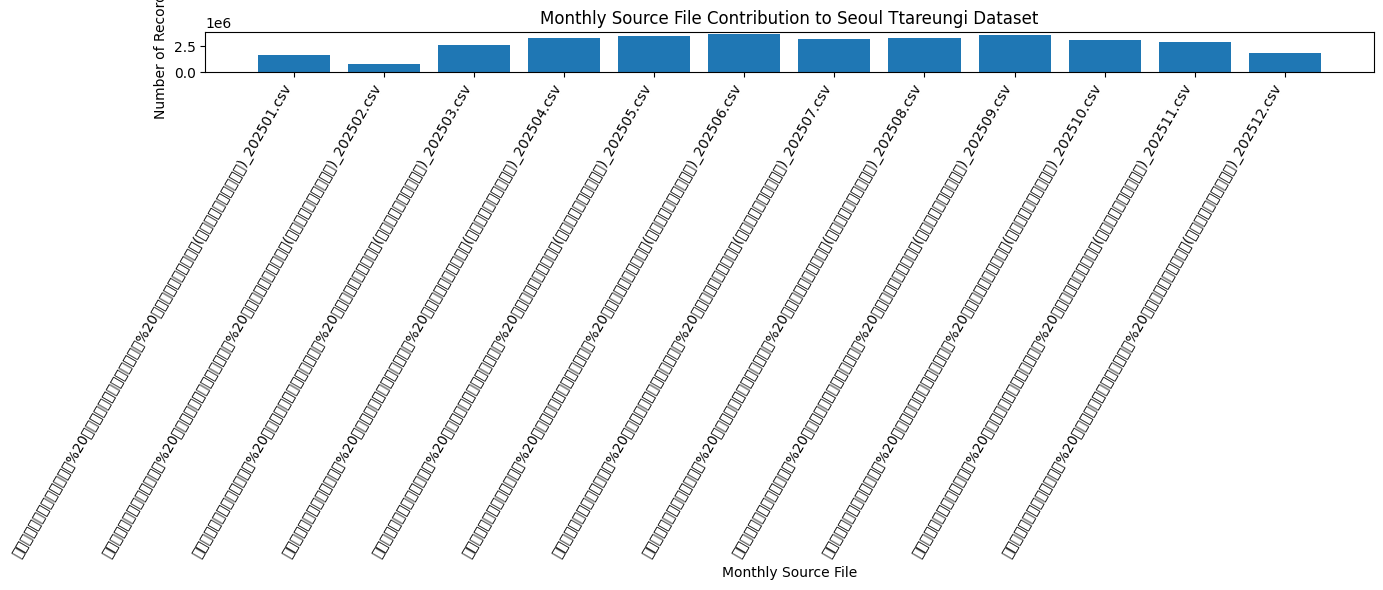

In [94]:
# ============================================================
# CELL 26 — Source file contribution visualization
# ============================================================

plt.figure(figsize=(14, 6))

plt.bar(
    source_file_pd["source_file"],
    source_file_pd["count"]
)

plt.xlabel("Monthly Source File")
plt.ylabel("Number of Records")
plt.title(
    "Monthly Source File Contribution to Seoul Ttareungi Dataset"
)

plt.xticks(
    rotation=60,
    ha="right"
)

plt.tight_layout()
plt.show()

In [95]:
# ============================================================
# CELL 27 — ANALYSIS 1: Hourly bicycle demand
# ============================================================

hourly_demand = (
    df_final
    .groupBy("rental_hour")
    .agg(
        F.sum("usage_count").alias("total_usage")
    )
    .orderBy("rental_hour")
)

hourly_pd = hourly_demand.toPandas()

display(hourly_pd)

,rental_hour,total_usage
0,0,706260
1,1,497537
2,2,332367
3,3,242610
4,4,208937
5,5,398160
6,6,841957
7,7,1954567
8,8,2817074
9,9,1593900


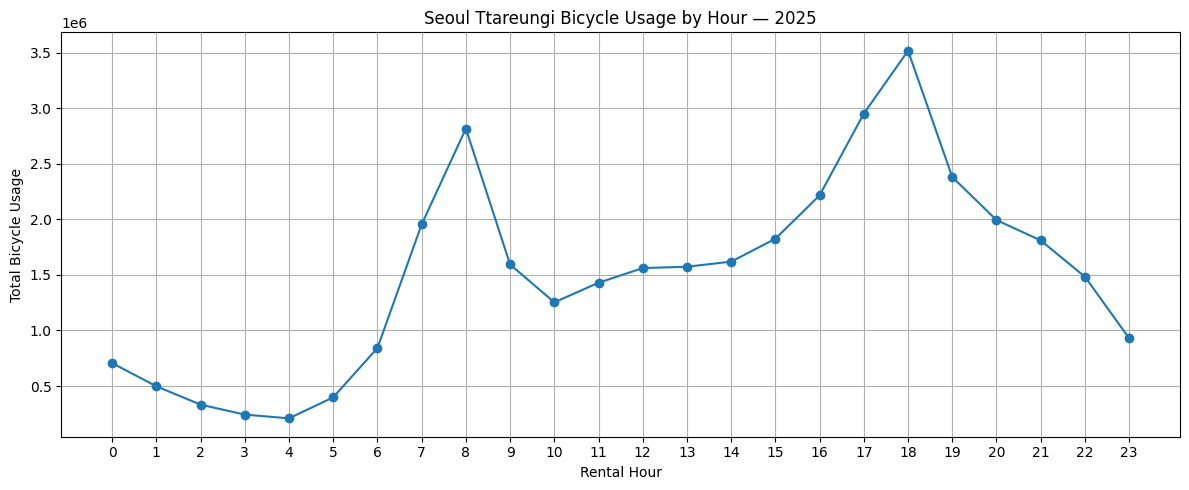

In [96]:
# ============================================================
# CELL 28 — Hourly demand visualization
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    hourly_pd["rental_hour"],
    hourly_pd["total_usage"],
    marker="o"
)

plt.xlabel("Rental Hour")
plt.ylabel("Total Bicycle Usage")
plt.title(
    "Seoul Ttareungi Bicycle Usage by Hour — 2025"
)

plt.xticks(range(24))
plt.grid()
plt.tight_layout()
plt.show()

In [97]:
# ============================================================
# CELL 29 — Peak and lowest demand hours
# ============================================================

peak_hour = hourly_pd.loc[
    hourly_pd["total_usage"].idxmax()
]

lowest_hour = hourly_pd.loc[
    hourly_pd["total_usage"].idxmin()
]

print("=" * 60)
print("HOURLY DEMAND FINDINGS")
print("=" * 60)

print(
    "Peak Hour:",
    int(peak_hour["rental_hour"])
)

print(
    "Peak Usage:",
    f"{int(peak_hour['total_usage']):,}"
)

print()

print(
    "Lowest Hour:",
    int(lowest_hour["rental_hour"])
)

print(
    "Lowest Usage:",
    f"{int(lowest_hour['total_usage']):,}"
)

HOURLY DEMAND FINDINGS
Peak Hour: 18
Peak Usage: 3,518,076

Lowest Hour: 4
Lowest Usage: 208,937


In [98]:
# ============================================================
# CELL 30 — ANALYSIS 2: Monthly bicycle demand
# ============================================================

monthly_demand = (
    df_final
    .groupBy("month")
    .agg(
        F.sum("usage_count").alias("total_usage")
    )
    .orderBy("month")
)

monthly_pd = monthly_demand.toPandas()

display(monthly_pd)

,month,total_usage
0,1,1652072
1,2,774991
2,3,2842804
3,4,3594746
4,5,3824609
5,6,3993763
6,7,3509497
7,8,3532209
8,9,3959351
9,10,3372405


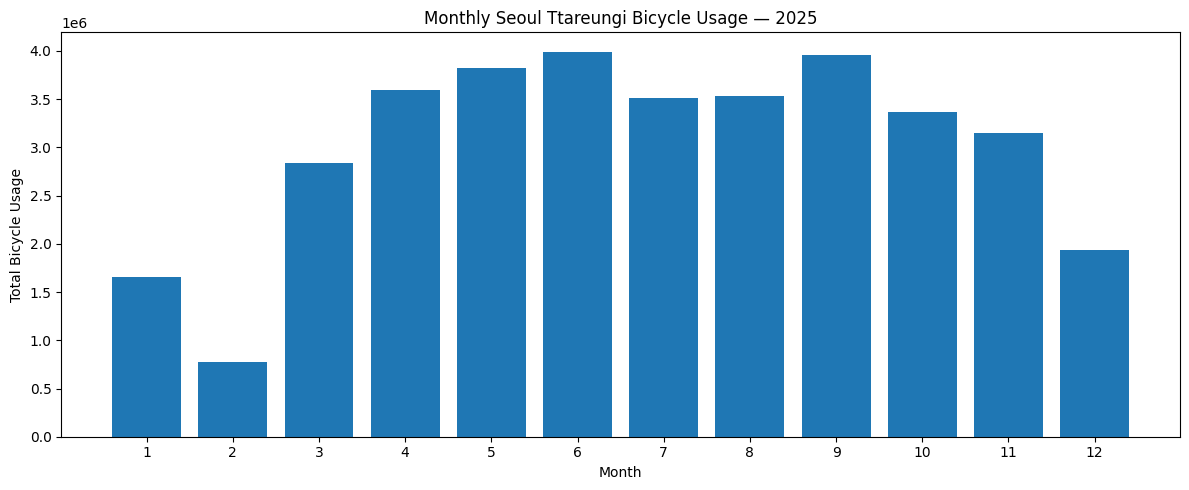

In [99]:
# ============================================================
# CELL 31 — Monthly demand visualization
# ============================================================

plt.figure(figsize=(12, 5))

plt.bar(
    monthly_pd["month"],
    monthly_pd["total_usage"]
)

plt.xlabel("Month")
plt.ylabel("Total Bicycle Usage")
plt.title(
    "Monthly Seoul Ttareungi Bicycle Usage — 2025"
)

plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

In [100]:
# ============================================================
# CELL 32 — Monthly demand findings
# ============================================================

peak_month = monthly_pd.loc[
    monthly_pd["total_usage"].idxmax()
]

lowest_month = monthly_pd.loc[
    monthly_pd["total_usage"].idxmin()
]

print("=" * 60)
print("MONTHLY DEMAND FINDINGS")
print("=" * 60)

print(
    "Highest Usage Month:",
    int(peak_month["month"])
)

print(
    "Usage:",
    f"{int(peak_month['total_usage']):,}"
)

print()

print(
    "Lowest Usage Month:",
    int(lowest_month["month"])
)

print(
    "Usage:",
    f"{int(lowest_month['total_usage']):,}"
)

MONTHLY DEMAND FINDINGS
Highest Usage Month: 6
Usage: 3,993,763

Lowest Usage Month: 2
Usage: 774,991


In [101]:
# ============================================================
# CELL 33 — ANALYSIS 3: Top 10 stations
# ============================================================

top_stations = (
    df_final
    .groupBy(
        "station_id",
        "station_name"
    )
    .agg(
        F.sum("usage_count").alias(
            "total_usage"
        )
    )
    .orderBy(
        F.desc("total_usage")
    )
    .limit(10)
)

top_stations_pd = top_stations.toPandas()

display(top_stations_pd)

,station_id,station_name,total_usage
0,02715,2715.마곡나루역 2번 출구,158009
1,01210,1210. 롯데월드타워(잠실역2번출구 쪽),107134
2,02728,2728.마곡나루역 3번 출구,105476
3,02701,2701. 마곡나루역 5번출구 뒤편,103766
4,00502,502. 자양(뚝섬한강공원)역 1번출구 앞,92882
5,04217,4217. 한강공원 망원나들목,86770
6,01153,"1153. 발산역 1번, 9번 인근 대여소",83092
7,02608,2608. 송파구청,67763
8,02622,2622. 올림픽공원역 3번출구,66390
9,01124,1124. 발산역 6번 출구 뒤,66104


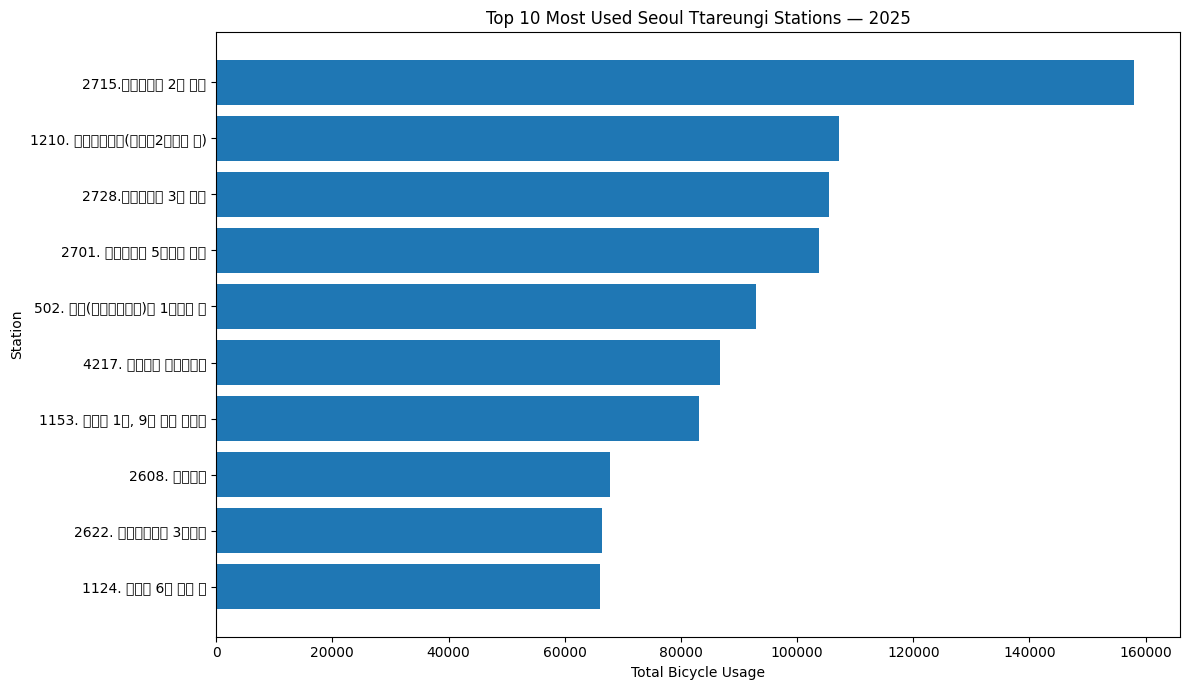

In [102]:
# ============================================================
# CELL 34 — Top station visualization
# ============================================================

plt.figure(figsize=(12, 7))

plt.barh(
    top_stations_pd["station_name"].astype(str),
    top_stations_pd["total_usage"]
)

plt.xlabel("Total Bicycle Usage")
plt.ylabel("Station")
plt.title(
    "Top 10 Most Used Seoul Ttareungi Stations — 2025"
)

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [103]:
# ============================================================
# CELL 35 — ANALYSIS 4: Weekday vs Weekend
# ============================================================

daytype_demand = (
    df_final
    .groupBy("day_type")
    .agg(
        F.sum("usage_count").alias(
            "total_usage"
        )
    )
    .orderBy(
        F.desc("total_usage")
    )
)

daytype_pd = daytype_demand.toPandas()

display(daytype_pd)

,day_type,total_usage
0,Weekday,27570537
1,Weekend,8570689


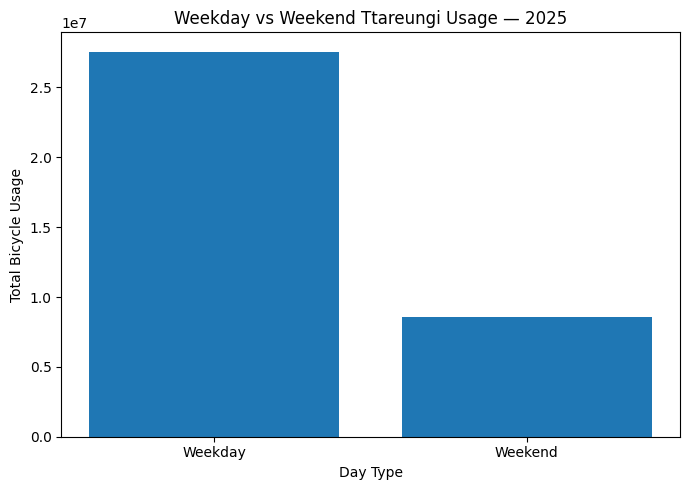

In [104]:
# ============================================================
# CELL 36 — Weekday vs Weekend visualization
# ============================================================

plt.figure(figsize=(7, 5))

plt.bar(
    daytype_pd["day_type"],
    daytype_pd["total_usage"]
)

plt.xlabel("Day Type")
plt.ylabel("Total Bicycle Usage")
plt.title(
    "Weekday vs Weekend Ttareungi Usage — 2025"
)

plt.tight_layout()
plt.show()

In [105]:
# ============================================================
# CELL 37 — ANALYSIS 5: Gender usage
# ============================================================

gender_usage = (
    df_final
    .filter(
        F.col("gender").isNotNull() &
        (F.trim(F.col("gender")) != "")
    )
    .groupBy("gender")
    .agg(
        F.sum("usage_count").alias(
            "total_usage"
        )
    )
    .orderBy(
        F.desc("total_usage")
    )
)

gender_pd = gender_usage.toPandas()

display(gender_pd)

,gender,total_usage
0,M,17533381
1,F,9450829
2,m,3419
3,f,1639


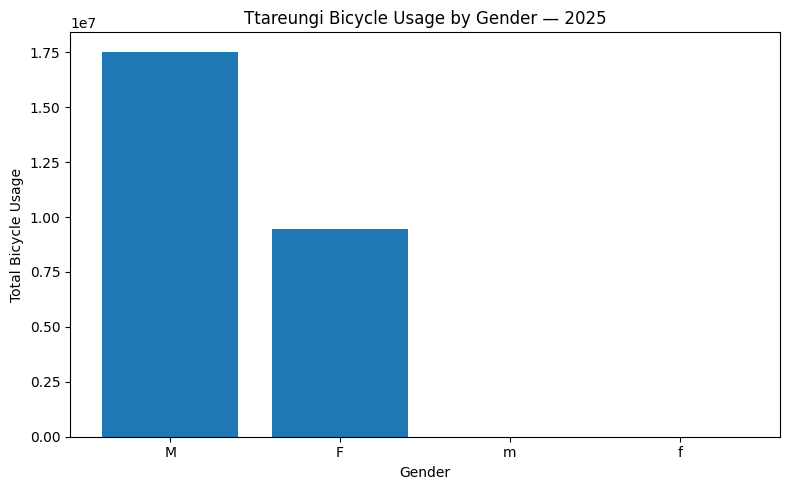

In [106]:
# ============================================================
# CELL 38— Gender visualization
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    gender_pd["gender"].astype(str),
    gender_pd["total_usage"]
)

plt.xlabel("Gender")
plt.ylabel("Total Bicycle Usage")
plt.title(
    "Ttareungi Bicycle Usage by Gender — 2025"
)

plt.tight_layout()
plt.show()

In [107]:
# ============================================================
# CELL 39 — ANALYSIS 6: Age-group usage
# ============================================================

age_usage = (
    df_final
    .filter(
        F.col("age_group").isNotNull() &
        (F.trim(F.col("age_group")) != "")
    )
    .groupBy("age_group")
    .agg(
        F.sum("usage_count").alias(
            "total_usage"
        )
    )
    .orderBy(
        F.desc("total_usage")
    )
)

age_pd = age_usage.toPandas()

display(age_pd)

,age_group,total_usage
0,30s,9796513
1,20s,9385416
2,40s,6115837
3,50s,4294349
4,기타,2455767
5,Under 10,2231630
6,60s,1571152
7,70대이상,290562


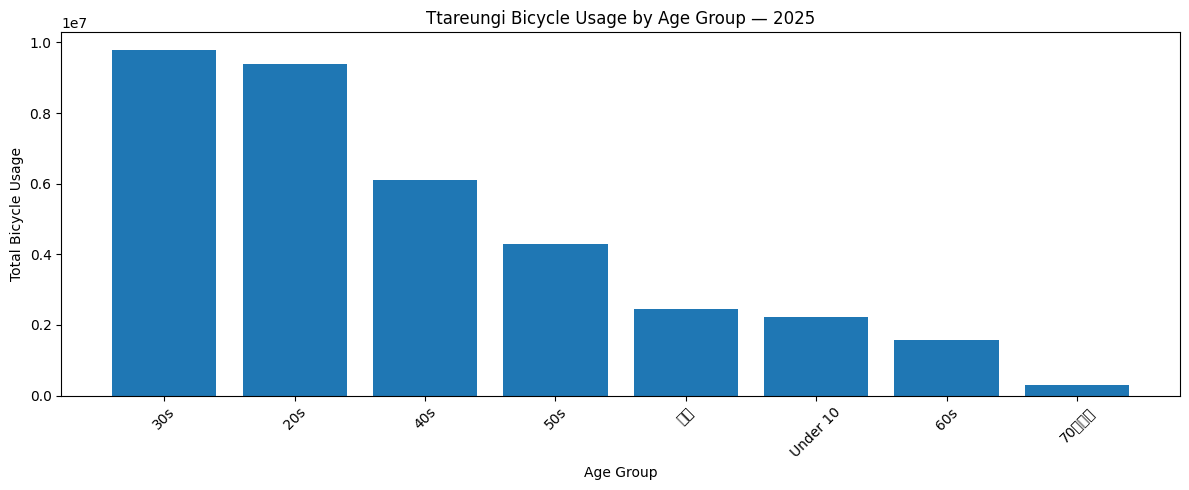

In [108]:
# ============================================================
# CELL 40 — Age-group visualization
# ============================================================

plt.figure(figsize=(12, 5))

plt.bar(
    age_pd["age_group"].astype(str),
    age_pd["total_usage"]
)

plt.xlabel("Age Group")
plt.ylabel("Total Bicycle Usage")
plt.title(
    "Ttareungi Bicycle Usage by Age Group — 2025"
)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [109]:
# ============================================================
# CELL 41 — ANALYSIS 7: Rental type
# ============================================================

rental_type_usage = (
    df_final
    .filter(
        F.col("rental_type").isNotNull() &
        (F.trim(F.col("rental_type")) != "")
    )
    .groupBy("rental_type")
    .agg(
        F.sum("usage_count").alias(
            "total_usage"
        )
    )
    .orderBy(
        F.desc("total_usage")
    )
)

rental_type_pd = rental_type_usage.toPandas()

display(rental_type_pd)

,rental_type,total_usage
0,Annual Pass,30073030
1,Daily Pass,5748308
2,일일권(비회원),280547
3,가족권,24637
4,가족권(2시간),9185
5,일일권(3시간),4641
6,일일권(비회원 3시간),660
7,가족권(3시간),218


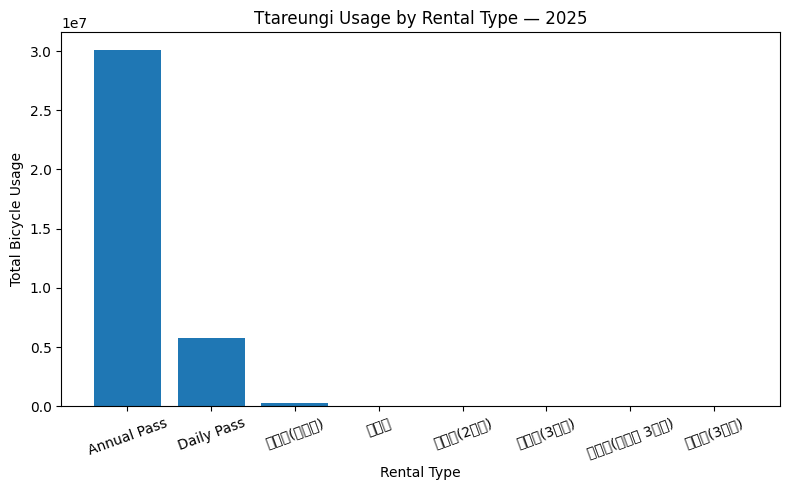

In [110]:
# ============================================================
# CELL 42 — Rental type visualization
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    rental_type_pd["rental_type"].astype(str),
    rental_type_pd["total_usage"]
)

plt.xlabel("Rental Type")
plt.ylabel("Total Bicycle Usage")
plt.title(
    "Ttareungi Usage by Rental Type — 2025"
)

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [111]:
# ============================================================
# CELL 43 — Distance distribution
# ============================================================

distance_pd = (
    df_final
    .select("distance_m")
    .dropna()
    .sample(
        withReplacement=False,
        fraction=0.05,
        seed=42
    )
    .toPandas()
)

display(distance_pd.describe())

,distance_m
count,1.650224e+06
mean,2.557838e+03
std,3.272894e+03
min,1.000000e-01
25%,8.428200e+02
50%,1.498510e+03
75%,2.870000e+03
max,1.259360e+05


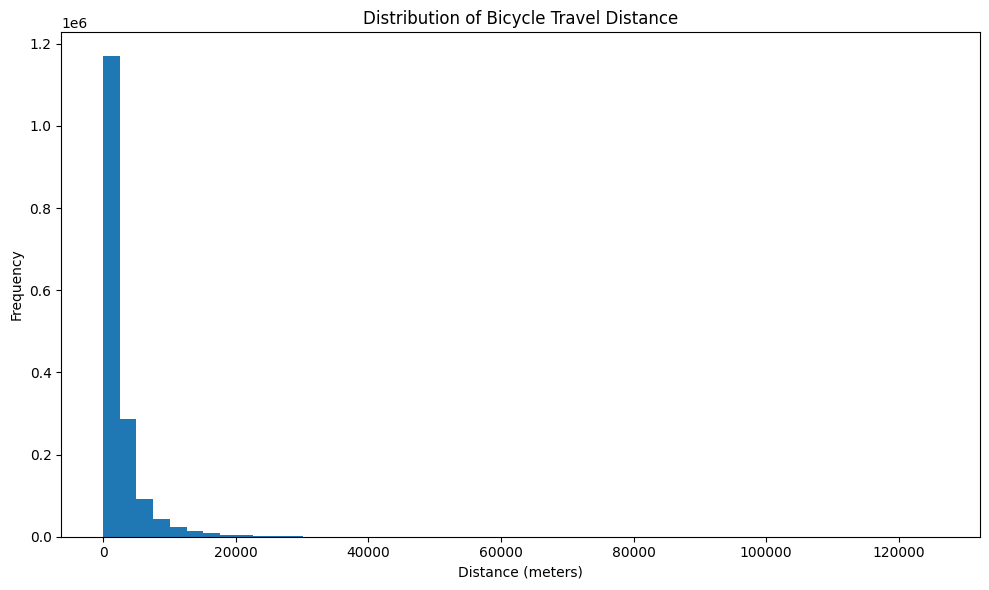

In [112]:
# ============================================================
# CELL 44 — Distance distribution visualization
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    distance_pd["distance_m"],
    bins=50
)

plt.xlabel("Distance (meters)")
plt.ylabel("Frequency")
plt.title(
    "Distribution of Bicycle Travel Distance"
)

plt.tight_layout()
plt.show()

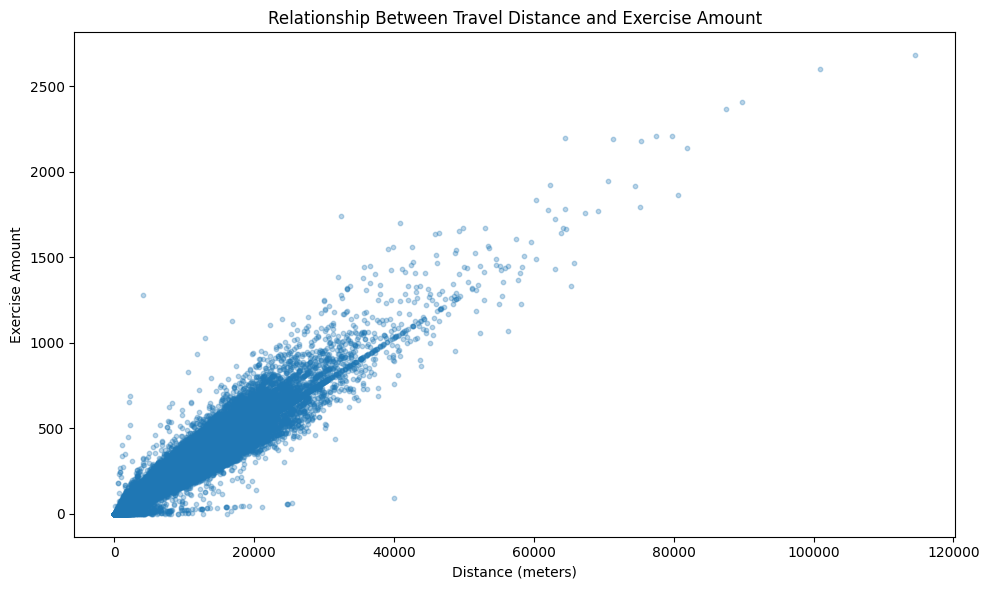

In [114]:
# ============================================================
# CELL 45 — Exercise vs Distance
# ============================================================

exercise_distance_pd = (
    df_final
    .select(
        "distance_m",
        "exercise_amount"
    )
    .dropna()
    .sample(
        withReplacement=False,
        fraction=0.02,
        seed=42
    )
    .toPandas()
)

plt.figure(figsize=(10, 6))

plt.scatter(
    exercise_distance_pd["distance_m"],
    exercise_distance_pd["exercise_amount"],
    alpha=0.3,
    s=10
)

plt.xlabel("Distance (meters)")
plt.ylabel("Exercise Amount")
plt.title(
    "Relationship Between Travel Distance and Exercise Amount"
)

plt.tight_layout()
plt.show()

In [115]:
# ============================================================
# CELL 46 — Distance, exercise and carbon statistics
# ============================================================

transport_statistics = df_final.select(

    F.sum("usage_count").alias(
        "total_usage"
    ),

    F.avg("distance_m").alias(
        "average_distance_m"
    ),

    F.sum("distance_m").alias(
        "total_distance_m"
    ),

    F.avg("exercise_amount").alias(
        "average_exercise"
    ),

    F.sum("exercise_amount").alias(
        "total_exercise"
    ),

    F.avg("carbon_saved").alias(
        "average_carbon_saved"
    ),

    F.sum("carbon_saved").alias(
        "total_carbon_saved"
    )

)

transport_statistics.show(
    truncate=False
)

+-----------+------------------+--------------------+-----------------+------------------+--------------------+--------------------+
|total_usage|average_distance_m|total_distance_m    |average_exercise |total_exercise    |average_carbon_saved|total_carbon_saved  |
+-----------+------------------+--------------------+-----------------+------------------+--------------------+--------------------+
|36141226   |2559.8844114188187|8.447096597250613E10|68.51328894907526|2.25142382082997E9|0.5935521275203064  |1.9504791250012856E7|
+-----------+------------------+--------------------+-----------------+------------------+--------------------+--------------------+



In [117]:
# ============================================================
# CELL 47 — Correlation analysis
# ============================================================

numeric_features = [
    "rental_hour",
    "usage_count",
    "exercise_amount",
    "carbon_saved",
    "distance_m"
]

correlation_matrix = []

for feature1 in numeric_features:

    row = []

    for feature2 in numeric_features:

        correlation = df_final.stat.corr(
            feature1,
            feature2
        )

        row.append(correlation)

    correlation_matrix.append(row)

correlation_pd = pd.DataFrame(
    correlation_matrix,
    index=numeric_features,
    columns=numeric_features
)

display(correlation_pd)

,rental_hour,usage_count,exercise_amount,carbon_saved,distance_m
rental_hour,1.000000,0.025008,0.069309,0.077504,0.077617
usage_count,0.025008,1.000000,0.233597,0.247542,0.248866
exercise_amount,0.069309,0.233597,1.000000,0.960261,0.957295
carbon_saved,0.077504,0.247542,0.960261,1.000000,0.996908
distance_m,0.077617,0.248866,0.957295,0.996908,1.000000


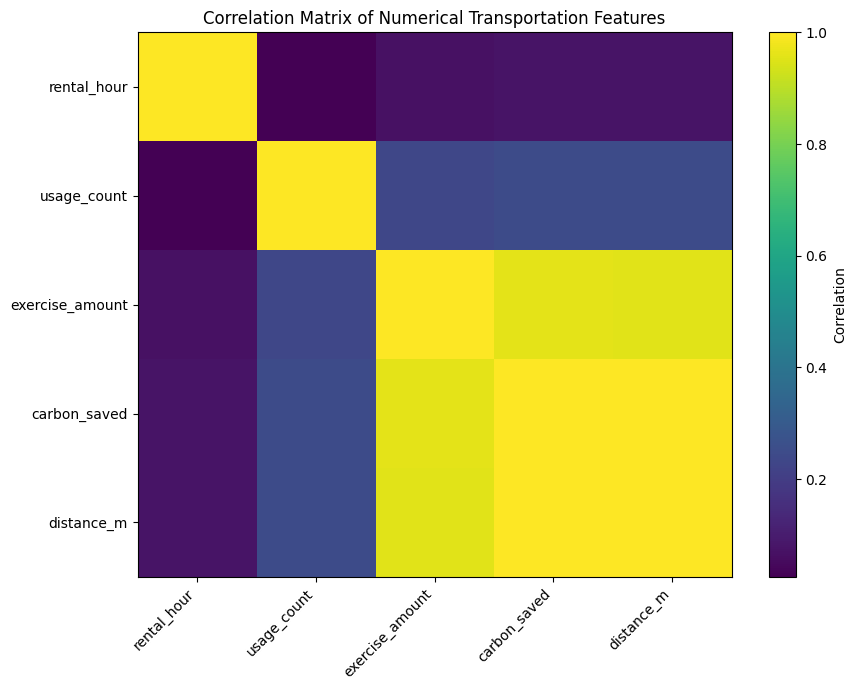

In [118]:
# ============================================================
# CELL 48 — Correlation heatmap
# ============================================================

plt.figure(figsize=(9, 7))

plt.imshow(
    correlation_pd,
    aspect="auto"
)

plt.colorbar(
    label="Correlation"
)

plt.xticks(
    range(len(numeric_features)),
    numeric_features,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(numeric_features)),
    numeric_features
)

plt.title(
    "Correlation Matrix of Numerical Transportation Features"
)

plt.tight_layout()
plt.show()

In [119]:
# ============================================================
# CELL 49 — IQR outlier analysis
# ============================================================

distance_for_outlier = (
    df_final
    .filter(
        F.col("distance_m").isNotNull()
    )
)

quantiles = (
    distance_for_outlier
    .approxQuantile(
        "distance_m",
        [0.25, 0.75],
        0.01
    )
)

Q1 = quantiles[0]
Q3 = quantiles[1]

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 840.0
Q3: 2808.75
IQR: 1968.75
Lower Bound: -2113.125
Upper Bound: 5761.875


In [120]:
# ============================================================
# CELL 50 — Distance outlier count
# ============================================================

distance_outliers = (
    distance_for_outlier
    .filter(
        (F.col("distance_m") < lower_bound) |
        (F.col("distance_m") > upper_bound)
    )
)

outlier_count = distance_outliers.count()

distance_total_count = (
    distance_for_outlier.count()
)

outlier_percentage = (
    outlier_count /
    distance_total_count * 100
    if distance_total_count > 0
    else 0
)

print("=" * 60)
print("DISTANCE OUTLIER ANALYSIS")
print("=" * 60)

print(
    "Distance records:",
    f"{distance_total_count:,}"
)

print(
    "Distance outliers:",
    f"{outlier_count:,}"
)

print(
    "Outlier percentage:",
    f"{outlier_percentage:.2f}%"
)

DISTANCE OUTLIER ANALYSIS
Distance records: 32,997,961
Distance outliers: 3,216,964
Outlier percentage: 9.75%


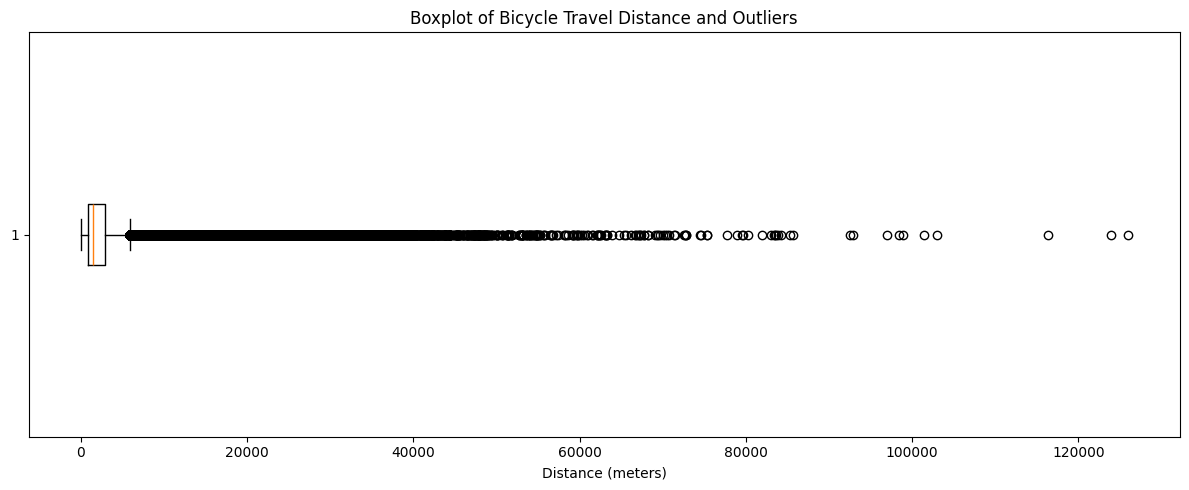

In [121]:
# ============================================================
# CELL 51 — Distance outlier visualization
# ============================================================

plt.figure(figsize=(12, 5))

plt.boxplot(
    distance_pd["distance_m"],
    vert=False
)

plt.xlabel("Distance (meters)")
plt.title(
    "Boxplot of Bicycle Travel Distance and Outliers"
)

plt.tight_layout()
plt.show()

In [122]:
# ============================================================
# CELL 52 — PCA preparation
# ============================================================

from pyspark.ml.feature import (
    VectorAssembler,
    StandardScaler,
    PCA
)

pca_features = [
    "rental_hour",
    "usage_count",
    "exercise_amount",
    "carbon_saved",
    "distance_m"
]

pca_df = (
    df_final
    .select(*pca_features)
    .dropna()
)

pca_count = pca_df.count()

print(
    "Records available for PCA:",
    f"{pca_count:,}"
)

print(
    "PCA features:",
    pca_features
)

Records available for PCA: 32,861,126
PCA features: ['rental_hour', 'usage_count', 'exercise_amount', 'carbon_saved', 'distance_m']


In [123]:
# ============================================================
# CELL 53 — Assemble PCA features
# ============================================================

assembler = VectorAssembler(
    inputCols=pca_features,
    outputCol="features"
)

assembled_df = assembler.transform(
    pca_df
)

assembled_df.select(
    "features"
).show(
    5,
    truncate=False
)

+-----------------------------+
|features                     |
+-----------------------------+
|[7.0,1.0,32.77,0.24,1034.55] |
|[8.0,7.0,156.1,1.21,5190.9]  |
|[8.0,1.0,16.3,0.13,563.98]   |
|[16.0,1.0,43.23,0.43,1850.22]|
|[17.0,1.0,48.94,0.44,1901.35]|
+-----------------------------+
only showing top 5 rows


In [124]:
# ============================================================
# CELL 54 — Standardize PCA features
# ============================================================

scaler = StandardScaler(
    inputCol="features",
    outputCol="scaledFeatures",
    withStd=True,
    withMean=True
)

scaler_model = scaler.fit(
    assembled_df
)

scaled_df = scaler_model.transform(
    assembled_df
)

scaled_df.select(
    "scaledFeatures"
).show(
    5,
    truncate=False
)

+--------------------------------------------------------------------------------------------------------+
|scaledFeatures                                                                                          |
+--------------------------------------------------------------------------------------------------------+
|[-1.2056983318269778,-0.23997742208281786,-0.3901714637228471,-0.46684916311402025,-0.46699356582076323]|
|[-1.0307814299929976,14.814800061772177,0.956090954643291,0.8139907837340119,0.805075945633777]         |
|[-1.0307814299929976,-0.23997742208281786,-0.5699569338476367,-0.6120990539936939,-0.6110136194748499]  |
|[0.36855378467884337,-0.23997742208281786,-0.2759907704924101,-0.2159629879582201,-0.2173541133184174]  |
|[0.5434706865128235,-0.23997742208281786,-0.21366077447464757,-0.2027584524237043,-0.20170554808193095] |
+--------------------------------------------------------------------------------------------------------+
only showing top 5 rows


In [125]:
# ============================================================
# CELL 55 — Run PCA
# ============================================================

pca = PCA(
    k=len(pca_features),
    inputCol="scaledFeatures",
    outputCol="pcaFeatures"
)

pca_model = pca.fit(
    scaled_df
)

pca_result = pca_model.transform(
    scaled_df
)

explained_variance = (
    pca_model
    .explainedVariance
    .toArray()
)

print("=" * 60)
print("PCA EXPLAINED VARIANCE")
print("=" * 60)

for i, variance in enumerate(
    explained_variance,
    1
):

    print(
        f"PC{i}: "
        f"{variance * 100:.2f}%"
    )

print("\nCUMULATIVE EXPLAINED VARIANCE")

cumulative = 0

for i, variance in enumerate(
    explained_variance,
    1
):

    cumulative += variance

    print(
        f"PC1 to PC{i}: "
        f"{cumulative * 100:.2f}%"
    )

PCA EXPLAINED VARIANCE
PC1: 60.84%
PC2: 19.83%
PC3: 18.26%
PC4: 1.06%
PC5: 0.01%

CUMULATIVE EXPLAINED VARIANCE
PC1 to PC1: 60.84%
PC1 to PC2: 80.67%
PC1 to PC3: 98.93%
PC1 to PC4: 99.99%
PC1 to PC5: 100.00%


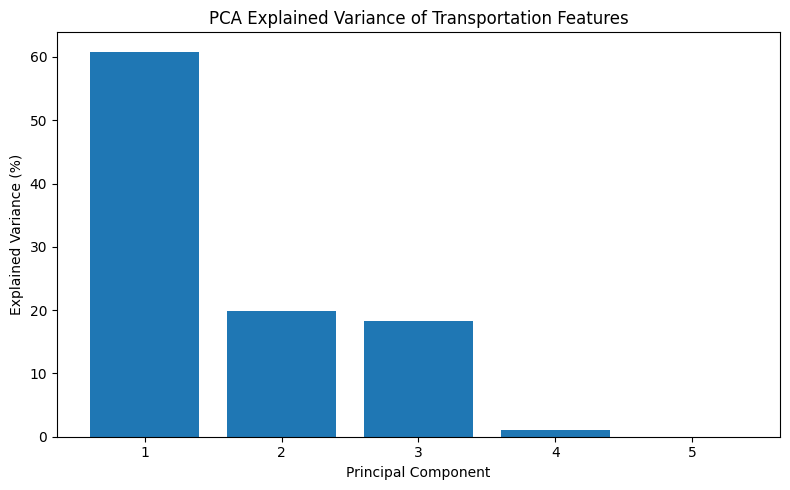

In [126]:
# ============================================================
# CELL 56 — PCA explained variance visualization
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    range(
        1,
        len(explained_variance) + 1
    ),
    explained_variance * 100
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance (%)")
plt.title(
    "PCA Explained Variance of Transportation Features"
)

plt.xticks(
    range(
        1,
        len(explained_variance) + 1
    )
)

plt.tight_layout()
plt.show()

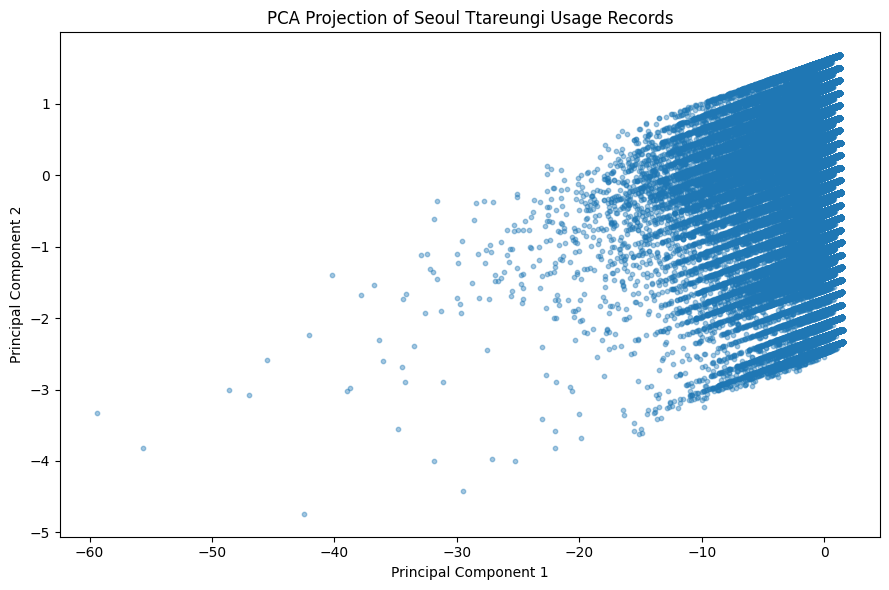

In [127]:
# ============================================================
# CELL 57 — PCA 2D visualization
# ============================================================

pca_sample_pd = (
    pca_result
    .select("pcaFeatures")
    .sample(
        withReplacement=False,
        fraction=0.02,
        seed=42
    )
    .toPandas()
)

pca_sample_pd["PC1"] = (
    pca_sample_pd["pcaFeatures"]
    .apply(lambda x: float(x[0]))
)

pca_sample_pd["PC2"] = (
    pca_sample_pd["pcaFeatures"]
    .apply(lambda x: float(x[1]))
)

plt.figure(figsize=(9, 6))

plt.scatter(
    pca_sample_pd["PC1"],
    pca_sample_pd["PC2"],
    alpha=0.4,
    s=10
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title(
    "PCA Projection of Seoul Ttareungi Usage Records"
)

plt.tight_layout()
plt.show()

In [128]:
# ============================================================
# CELL 58 — PCA component loadings
# ============================================================

pc_matrix = (
    pca_model
    .pc
    .toArray()
)

pca_loadings = pd.DataFrame(
    pc_matrix,
    index=pca_features,
    columns=[
        f"PC{i}"
        for i in range(
            1,
            len(pca_features) + 1
        )
    ]
)

print("PCA COMPONENT LOADINGS")

display(pca_loadings)

PCA COMPONENT LOADINGS


,PC1,PC2,PC3,PC4,PC5
rental_hour,-0.064615,0.997641,0.022351,0.006199,-0.000007
usage_count,-0.202362,-0.035098,0.978622,0.010710,-0.001523
exercise_amount,-0.558382,-0.038436,-0.125799,0.819078,0.004279
carbon_saved,-0.567022,-0.031654,-0.115089,-0.402009,-0.708962
distance_m,-0.567071,-0.031653,-0.112821,-0.409082,0.705232


In [129]:
# ============================================================
# CELL 59 — Final transportation summary statistics
# ============================================================

final_statistics = df_final.select(

    F.sum("usage_count").alias(
        "Total_Usage"
    ),

    F.countDistinct(
        "station_id"
    ).alias(
        "Unique_Stations"
    ),

    F.countDistinct(
        "rental_date"
    ).alias(
        "Active_Days"
    ),

    F.avg(
        "distance_m"
    ).alias(
        "Average_Distance_m"
    ),

    F.sum(
        "distance_m"
    ).alias(
        "Total_Distance_m"
    ),

    F.avg(
        "exercise_amount"
    ).alias(
        "Average_Exercise"
    ),

    F.sum(
        "carbon_saved"
    ).alias(
        "Total_Carbon_Saved"
    )

)

final_statistics.show(
    truncate=False
)

+-----------+---------------+-----------+------------------+--------------------+-----------------+--------------------+
|Total_Usage|Unique_Stations|Active_Days|Average_Distance_m|Total_Distance_m    |Average_Exercise |Total_Carbon_Saved  |
+-----------+---------------+-----------+------------------+--------------------+-----------------+--------------------+
|36141226   |2811           |353        |2559.8844114188187|8.447096597250613E10|68.51328894907526|1.9504791250012856E7|
+-----------+---------------+-----------+------------------+--------------------+-----------------+--------------------+



In [130]:
# ============================================================
# CELL 60 — Key findings
# ============================================================

print("=" * 80)
print("KEY TRANSPORTATION FINDINGS")
print("=" * 80)

print(
    f"1. Peak rental hour: "
    f"{int(peak_hour['rental_hour'])}:00 "
    f"with "
    f"{int(peak_hour['total_usage']):,} uses."
)

print(
    f"2. Lowest rental hour: "
    f"{int(lowest_hour['rental_hour'])}:00 "
    f"with "
    f"{int(lowest_hour['total_usage']):,} uses."
)

print(
    f"3. Highest-demand month: "
    f"Month {int(peak_month['month'])} "
    f"with "
    f"{int(peak_month['total_usage']):,} uses."
)

print(
    f"4. Lowest-demand month: "
    f"Month {int(lowest_month['month'])} "
    f"with "
    f"{int(lowest_month['total_usage']):,} uses."
)

print(
    f"5. Distance outliers: "
    f"{outlier_count:,} records "
    f"({outlier_percentage:.2f}%)."
)

print(
    f"6. First two PCA components explain "
    f"{sum(explained_variance[:2]) * 100:.2f}% "
    f"of standardized numerical variance."
)

KEY TRANSPORTATION FINDINGS
1. Peak rental hour: 18:00 with 3,518,076 uses.
2. Lowest rental hour: 4:00 with 208,937 uses.
3. Highest-demand month: Month 6 with 3,993,763 uses.
4. Lowest-demand month: Month 2 with 774,991 uses.
5. Distance outliers: 3,216,964 records (9.75%).
6. First two PCA components explain 80.67% of standardized numerical variance.


In [131]:
# ============================================================
# CELL 61 — Save analysis results
# ============================================================

RESULT_FOLDER = (
    "/content/drive/MyDrive/"
    "Seoul_Ttareungi_2025_Results"
)

os.makedirs(
    RESULT_FOLDER,
    exist_ok=True
)

# Preprocessing
preprocessing_summary.to_csv(
    os.path.join(
        RESULT_FOLDER,
        "preprocessing_summary.csv"
    ),
    index=False
)

missing_pd.to_csv(
    os.path.join(
        RESULT_FOLDER,
        "missing_value_analysis.csv"
    ),
    index=False
)

# Source contribution
source_file_pd.to_csv(
    os.path.join(
        RESULT_FOLDER,
        "source_file_contribution.csv"
    ),
    index=False
)

# Demand
hourly_pd.to_csv(
    os.path.join(
        RESULT_FOLDER,
        "hourly_usage.csv"
    ),
    index=False
)

monthly_pd.to_csv(
    os.path.join(
        RESULT_FOLDER,
        "monthly_usage.csv"
    ),
    index=False
)

top_stations_pd.to_csv(
    os.path.join(
        RESULT_FOLDER,
        "top_stations.csv"
    ),
    index=False
)

# Demographics
daytype_pd.to_csv(
    os.path.join(
        RESULT_FOLDER,
        "weekday_weekend_usage.csv"
    ),
    index=False
)

gender_pd.to_csv(
    os.path.join(
        RESULT_FOLDER,
        "gender_usage.csv"
    ),
    index=False
)

age_pd.to_csv(
    os.path.join(
        RESULT_FOLDER,
        "age_group_usage.csv"
    ),
    index=False
)

rental_type_pd.to_csv(
    os.path.join(
        RESULT_FOLDER,
        "rental_type_usage.csv"
    ),
    index=False
)

# Correlation
correlation_pd.to_csv(
    os.path.join(
        RESULT_FOLDER,
        "correlation_matrix.csv"
    )
)

# PCA
pca_variance_pd = pd.DataFrame({
    "Principal_Component": [
        f"PC{i}"
        for i in range(
            1,
            len(explained_variance) + 1
        )
    ],
    "Explained_Variance_Percent":
        explained_variance * 100
})

pca_variance_pd.to_csv(
    os.path.join(
        RESULT_FOLDER,
        "pca_explained_variance.csv"
    ),
    index=False
)

pca_loadings.to_csv(
    os.path.join(
        RESULT_FOLDER,
        "pca_component_loadings.csv"
    )
)

print("=" * 60)
print("ALL RESULTS SAVED")
print("=" * 60)
print(RESULT_FOLDER)

ALL RESULTS SAVED
/content/drive/MyDrive/Seoul_Ttareungi_2025_Results


In [132]:
# ============================================================
# CELL 62 — FINAL EXPERIMENT SUMMARY
# ============================================================

print("=" * 80)
print(
    "SEOUL TTAREUNGI 2025 "
    "BIG DATA ANALYTICS EXPERIMENT"
)
print("=" * 80)

print("\nDATASET")
print(
    "Information on Public Bicycle Use "
    "in Seoul (by Time Zone)"
)
print("Period: January 2025 – December 2025")
print("Files processed:", len(files))

print(
    "Raw records:",
    f"{raw_count:,}"
)

print(
    "Final cleaned records:",
    f"{final_count:,}"
)

print("\nBIG DATA ENVIRONMENT")
print("Platform: Google Colab")
print("Framework: Apache Spark / PySpark")
print("Storage: Google Drive")
print("Prepared data format: UTF-8 CSV")
print("Analytical data format: Apache Parquet")

print("\nPREPROCESSING COMPLETED")
print("✓ Korean-to-English column mapping")
print("✓ UTF-8 encoding conversion")
print("✓ Data type conversion")
print("✓ Missing-value investigation")
print("✓ Missing essential-value treatment")
print("✓ Duplicate detection")
print("✓ Duplicate removal")
print("✓ Invalid/inconsistent record filtering")
print("✓ Feature engineering")
print("✓ IQR-based outlier detection")

print("\nANALYSIS COMPLETED")
print("✓ Source-file/month contribution")
print("✓ Hourly demand analysis")
print("✓ Peak and lowest hour identification")
print("✓ Monthly demand analysis")
print("✓ Highest and lowest month identification")
print("✓ Top 10 station analysis")
print("✓ Weekday vs weekend analysis")
print("✓ Gender analysis")
print("✓ Age-group analysis")
print("✓ Rental-type analysis")
print("✓ Travel-distance analysis")
print("✓ Exercise-distance relationship")
print("✓ Correlation analysis")
print("✓ Distance outlier analysis")
print("✓ PCA dimensionality reduction")
print("✓ PCA explained-variance analysis")
print("✓ PCA 2D visualization")
print("✓ PCA component loading analysis")

print("\nKEY FINDINGS")

print(
    "Peak hour:",
    int(peak_hour["rental_hour"]),
    "| Usage:",
    f"{int(peak_hour['total_usage']):,}"
)

print(
    "Peak month:",
    int(peak_month["month"]),
    "| Usage:",
    f"{int(peak_month['total_usage']):,}"
)

print(
    "Distance outliers:",
    f"{outlier_count:,}",
    f"({outlier_percentage:.2f}%)"
)

print(
    "First two PCA components explain:",
    f"{sum(explained_variance[:2]) * 100:.2f}%"
)

print("\nSTATUS: COMPLETE")
print("=" * 80)

SEOUL TTAREUNGI 2025 BIG DATA ANALYTICS EXPERIMENT

DATASET
Information on Public Bicycle Use in Seoul (by Time Zone)
Period: January 2025 – December 2025
Files processed: 12
Raw records: 33,396,750
Final cleaned records: 32,997,961

BIG DATA ENVIRONMENT
Platform: Google Colab
Framework: Apache Spark / PySpark
Storage: Google Drive
Prepared data format: UTF-8 CSV
Analytical data format: Apache Parquet

PREPROCESSING COMPLETED
✓ Korean-to-English column mapping
✓ UTF-8 encoding conversion
✓ Data type conversion
✓ Missing-value investigation
✓ Missing essential-value treatment
✓ Duplicate detection
✓ Duplicate removal
✓ Invalid/inconsistent record filtering
✓ Feature engineering
✓ IQR-based outlier detection

ANALYSIS COMPLETED
✓ Source-file/month contribution
✓ Hourly demand analysis
✓ Peak and lowest hour identification
✓ Monthly demand analysis
✓ Highest and lowest month identification
✓ Top 10 station analysis
✓ Weekday vs weekend analysis
✓ Gender analysis
✓ Age-group analysis
✓ Ren